#
*written by*  Mamello Malape_2023232750                            


Objective:
To investigate whether internet attention, measured using Google Trends, leads or
lags Bitcoin market activity, and to evaluate whether the attention indicator is a
useful predictor for Bitcoin market activity.

RESEARCH QUESTION:




 Does internet attention, as measured by Google Trends search indices, lead or lag Bitcoin market activity, and does it provide useful predictive information for Bitcoin returns, trading volume, and volatility?

Hypotheses

Lead–Lag Relationship

*  H₀: There is no lead–lag relationship between Google Trends and Bitcoin market activity

*  H₁: A lead–lag relationship exists


Granger Causality

*   H₀: Google Trends does not Granger-cause Bitcoin returns or trading volume

*  H₁: Google Trends Granger-causes Bitcoin returns or trading volume


Predictive Performance

*  H₀: Google Trends variables do not improve prediction accuracy
*  H₁: Google Trends variables improve prediction accuracy


 Volatility Effects



*   H₀: Attention variables are not significant in explaining Bitcoin volatility

*   H₁: Attention variables significantly explain Bitcoin volatility




##Packages

In [ ]:
!pip -q install yfinance pytrends statsmodels pandas
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 12.1 MB/s eta 0:00:00


##Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

import yfinance as yf
from pytrends.request import TrendReq
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests

from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input




plt.rcParams["figure.figsize"] = (12, 5)
np.random.seed(42)  # reproducibility

##Data Collection

In [ ]:
ticker = "BTC-USD"
start_date = "2025-01-01"
end_date   = "2025-12-31"
#get data from yahoo finance
data= yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)
print("Rows:", len(data))
display(data.head())
display(data.tail())

[*********************100%***********************]  1 of 1 completed

Rows: 364


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,,
2025-01-01,94419.757812,94419.757812,94929.867188,92788.125000,93425.101562,24519888919
2025-01-02,96886.875000,96886.875000,97739.820312,94201.570312,94416.289062,46009564411
2025-01-03,98107.429688,98107.429688,98956.914062,96034.617188,96881.726562,35611391163
2025-01-04,98236.226562,98236.226562,98734.429688,97562.976562,98106.992188,22342608078
2025-01-05,98314.960938,98314.960938,98813.304688,97291.765625,98233.906250,20525254825


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,,
2025-12-26,87301.429688,87301.429688,89459.429688,86628.140625,87235.507812,42455674908
2025-12-27,87802.156250,87802.156250,87874.781250,87182.976562,87301.429688,13741199310
2025-12-28,87835.835938,87835.835938,87986.890625,87394.953125,87799.343750,15156557929
2025-12-29,87138.140625,87138.140625,90299.156250,86717.914062,87835.789062,48411625849
2025-12-30,88430.132812,88430.132812,89297.937500,86735.546875,87134.351562,35586356225


In [ ]:
#Make use of Ajusted closing prices in there are not available make use of closing .

stock = pd.DataFrame(index=data.index)
if "Adj Close" in data.columns:
    stock = data[["Adj Close"]].rename(columns={"Adj Close": "price"})
else:
    stock = data[["Close"]].rename(columns={"Close": "price"})

    #Also Display Volumes
stock["volume"] = data[('Volume', ticker)]

stock.head()

Price,price,volume
Ticker,BTC-USD,
Date,,
2025-01-01,94419.757812,24519888919
2025-01-02,96886.875000,46009564411
2025-01-03,98107.429688,35611391163
2025-01-04,98236.226562,22342608078
2025-01-05,98314.960938,20525254825


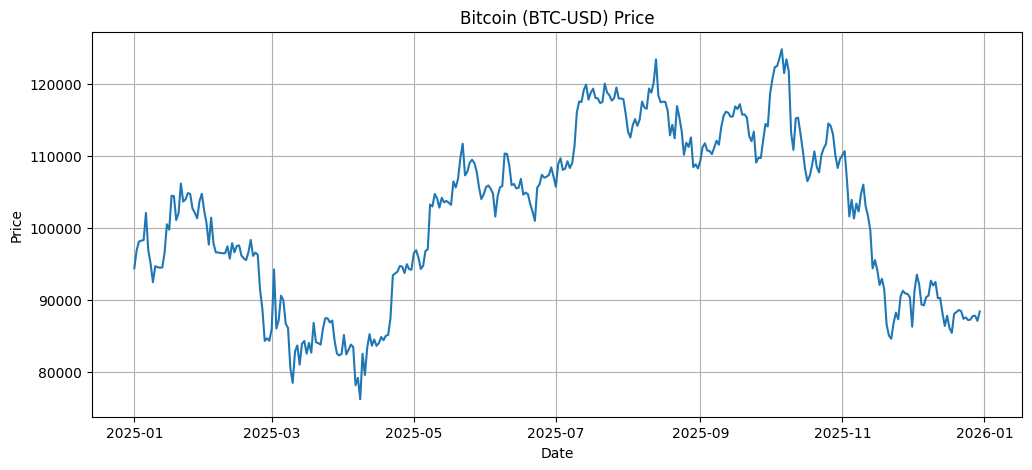

In [ ]:
##Visualise Raw price
plt.plot(stock.index, stock["price"])
plt.title("Bitcoin (BTC-USD) Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

Returns

In [ ]:
#
stock["log_price"] = np.log(stock["price"])
stock["log_return"] = stock["log_price"].diff()

display(stock.head(10))
print("Missing values in returns:")
print(stock[["log_return"]].isna().sum())

Price,price,volume,log_price,log_return
Ticker,BTC-USD,,,
Date,,,,
2025-01-01,94419.757812,24519888919,11.455506,NaN
2025-01-02,96886.875000,46009564411,11.481299,0.025794
2025-01-03,98107.429688,35611391163,11.493818,0.012519
2025-01-04,98236.226562,22342608078,11.495130,0.001312
2025-01-05,98314.960938,20525254825,11.495931,0.000801
2025-01-06,102078.085938,51823432705,11.533493,0.037562
2025-01-07,96922.703125,58685738547,11.481669,-0.051824
2025-01-08,95043.523438,63875859171,11.462090,-0.019579


Missing values in returns:
Price       Ticker
log_return            1
dtype: int64


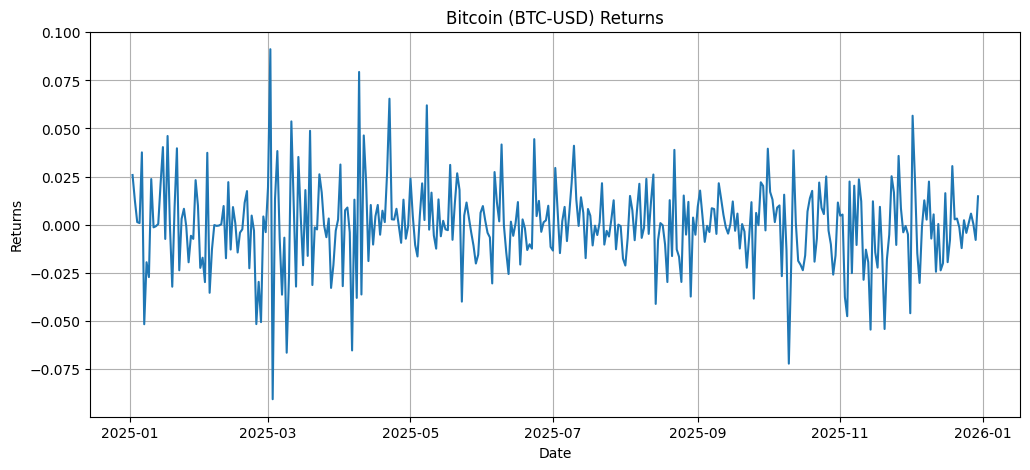

In [ ]:
##Visualise Raw price
plt.plot(stock.index, stock["log_return"])
plt.title("Bitcoin (BTC-USD) Returns")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.grid(True)
plt.show()

RETURN JUSTIFICATION:
  Log returns are used throughout this study. Log returns are preferred over
  simple percentage returns because they are time-additive (weekly log returns
  equal the sum of daily log returns), they are approximately normally distributed
  for short intervals, and they handle compounding effects consistently. This is
  consistent with standard practice in financial econometrics

In [ ]:
stock.index = pd.to_datetime(stock.index)

print(type(stock.index))
print(stock.index.min(), "to", stock.index.max())

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
2025-01-01 00:00:00 to 2025-12-30 00:00:00


In [ ]:
Bitcoin_data = stock[["price","volume","log_return"]].copy()

display(Bitcoin_data.head())

Price,price,volume,log_return
Ticker,BTC-USD,,
Date,,,
2025-01-01,94419.757812,24519888919,NaN
2025-01-02,96886.875000,46009564411,0.025794
2025-01-03,98107.429688,35611391163,0.012519
2025-01-04,98236.226562,22342608078,0.001312
2025-01-05,98314.960938,20525254825,0.000801


##Google Trends

In [ ]:
terms= ["Buy Bitcoin", "BTC", "BTC price","Ripple", "crypto"]
geo = "US"


KEYWORD JUSTIFICATION:
  Five search terms were selected to capture different dimensions of investor
  attention to Bitcoin and the broader crypto market:
  - "Buy Bitcoin"  : Direct transactional intent; signals active purchase interest
  - "BTC"          : Ticker-based attention from technically informed users
  - "BTC price"    : Price-checking behaviour; linked to valuation curiosity
  - "Ripple"       : Altcoin attention as a proxy for broader crypto market sentiment
  - "crypto"       : General cryptocurrency attention across all market participants
  These keywords align with Da, Engelberg & Gao (2011), who show that retail
  investor attention — proxied by search volume — predicts short-term stock returns.
  Kristoufek (2013) similarly demonstrates that Google Trends for "Bitcoin"
  correlates significantly with Bitcoin price dynamics.

In [ ]:
pytrends = TrendReq(hl="en-US", tz=360)
pytrends.build_payload(
    kw_list=terms,
    timeframe=f"{start_date} {end_date}",
    geo=geo
)

trends_raw = pytrends.interest_over_time()
print("Rows:", len(trends_raw))
display(trends_raw.head())

Rows: 53


,Buy Bitcoin,BTC,BTC price,Ripple,crypto,isPartial
date,,,,,,
2024-12-29,2,28,12,7,47,False
2025-01-05,2,30,13,7,44,False
2025-01-12,2,32,13,11,60,False
2025-01-19,4,40,16,9,100,False
2025-01-26,2,29,11,8,57,False


In [ ]:
trends = trends_raw.copy()

# Drop isPartial if present
if "isPartial" in trends.columns:
    trends = trends.drop(columns=["isPartial"])

trends.index = pd.to_datetime(trends.index)


# Weekly trends
trends_w = trends.resample("W-FRI").mean()


display(trends.head())
print("Missing values per column:")
print(trends.isna().sum())

,Buy Bitcoin,BTC,BTC price,Ripple,crypto
date,,,,,
2024-12-29,2,28,12,7,47
2025-01-05,2,30,13,7,44
2025-01-12,2,32,13,11,60
2025-01-19,4,40,16,9,100
2025-01-26,2,29,11,8,57


Missing values per column:
Buy Bitcoin    0
BTC            0
BTC price      0
Ripple         0
crypto         0
dtype: int64


Visualisation of Google Trends Keywords

##Align Frequencies(Weekly)

In [ ]:
# Weekly stock
stock_w = pd.DataFrame()
stock_w["price_w"] = stock["price"].resample("W").last()
stock_w["log_return_w"] = stock["log_return"].resample("W").sum()
stock_w["volume_w"] = stock["volume"].resample("W").sum()


# Weekly trends
trends_w = trends.resample("W").mean()

print("Weekly stock rows:", len(stock_w))
print("Weekly trends rows:", len(trends_w))
display(stock_w.head())

Weekly stock rows: 53
Weekly trends rows: 53


,price_w,log_return_w,volume_w
Date,,,
2025-01-05,98314.960938,0.040426,149008707396
2025-01-12,94488.437500,-0.039699,338967010865
2025-01-19,101089.609375,0.067530,437782936416
2025-01-26,102682.500000,0.015634,471816874719
2025-02-02,97688.976562,-0.049853,362117614322


,Buy Bitcoin,BTC,BTC price,Ripple,crypto
date,,,,,
2024-12-29,2.0,28.0,12.0,7.0,47.0
2025-01-05,2.0,30.0,13.0,7.0,44.0
2025-01-12,2.0,32.0,13.0,11.0,60.0
2025-01-19,4.0,40.0,16.0,9.0,100.0
2025-01-26,2.0,29.0,11.0,8.0,57.0


In [ ]:
#merge
df = stock_w.join(trends_w, how="inner")
print("Merged rows:", len(df))
display(df.head())
print("Missing values per column:")
print(df.isna().sum())

# Ensure datetime index
df.index = pd.to_datetime(df.index)
df = df.sort_index()

Merged rows: 52


,price_w,log_return_w,volume_w,Buy Bitcoin,BTC,BTC price,Ripple,crypto
2025-01-05,98314.960938,0.040426,149008707396,2.0,30.0,13.0,7.0,44.0
2025-01-12,94488.437500,-0.039699,338967010865,2.0,32.0,13.0,11.0,60.0
2025-01-19,101089.609375,0.067530,437782936416,4.0,40.0,16.0,9.0,100.0
2025-01-26,102682.500000,0.015634,471816874719,2.0,29.0,11.0,8.0,57.0
2025-02-02,97688.976562,-0.049853,362117614322,2.0,36.0,14.0,7.0,59.0


Missing values per column:
price_w         0
log_return_w    0
volume_w        0
Buy Bitcoin     0
BTC             0
BTC price       0
Ripple          0
crypto          0
dtype: int64


##Data prepossesing

In [ ]:
df = df.copy()

# Forward-fill trends
df[["Buy Bitcoin", "BTC", "BTC price","Ripple", "crypto"]] = df[["Buy Bitcoin", "BTC", "BTC price","Ripple", "crypto"]].ffill().bfill()



print("After cleaning, missing values:")
print(df.isna().sum())
display(df.head())

After cleaning, missing values:
price_w         0
log_return_w    0
volume_w        0
Buy Bitcoin     0
BTC             0
BTC price       0
Ripple          0
crypto          0
dtype: int64


,price_w,log_return_w,volume_w,Buy Bitcoin,BTC,BTC price,Ripple,crypto
2025-01-05,98314.960938,0.040426,149008707396,2.0,30.0,13.0,7.0,44.0
2025-01-12,94488.437500,-0.039699,338967010865,2.0,32.0,13.0,11.0,60.0
2025-01-19,101089.609375,0.067530,437782936416,4.0,40.0,16.0,9.0,100.0
2025-01-26,102682.500000,0.015634,471816874719,2.0,29.0,11.0,8.0,57.0
2025-02-02,97688.976562,-0.049853,362117614322,2.0,36.0,14.0,7.0,59.0


##Visualise merged data

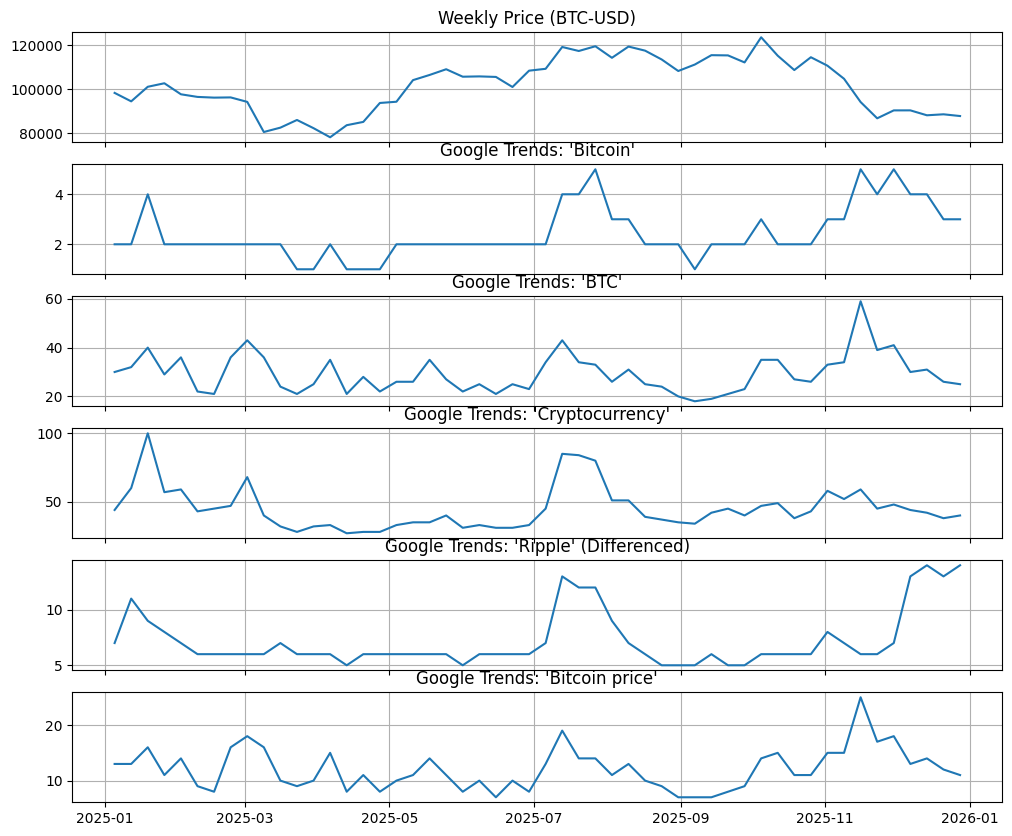

In [ ]:
fig, ax = plt.subplots(6, 1, figsize=(12, 10), sharex=True)

ax[0].plot(df.index, df["price_w"])
ax[0].set_title("Weekly Price (BTC-USD)")
ax[0].grid(True)




ax[1].plot(df.index, df["Buy Bitcoin"])
ax[1].set_title("Google Trends: 'Bitcoin'")
ax[1].grid(True)

ax[2].plot(df.index, df["BTC"])
ax[2].set_title("Google Trends: 'BTC'")
ax[2].grid(True)


ax[3].plot(df.index, df["crypto"])
ax[3].set_title("Google Trends: 'Cryptocurrency'")
ax[3].grid(True)

ax[4].plot(df.index, df["Ripple"])
ax[4].set_title("Google Trends: 'Ripple' (Differenced)")
ax[4].grid(True)

ax[5].plot(df.index, df["BTC price"])
ax[5].set_title("Google Trends: 'Bitcoin price'")
ax[5].grid(True)



plt.show()

##Rolling Windows

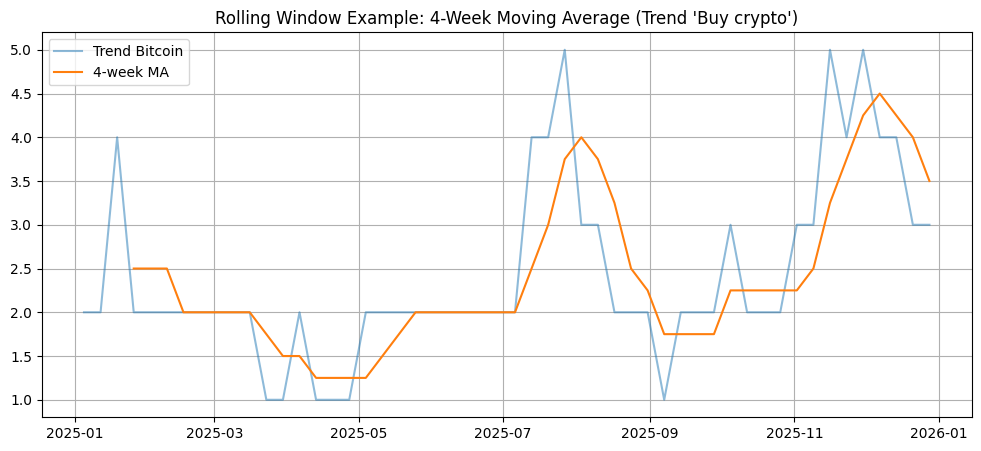

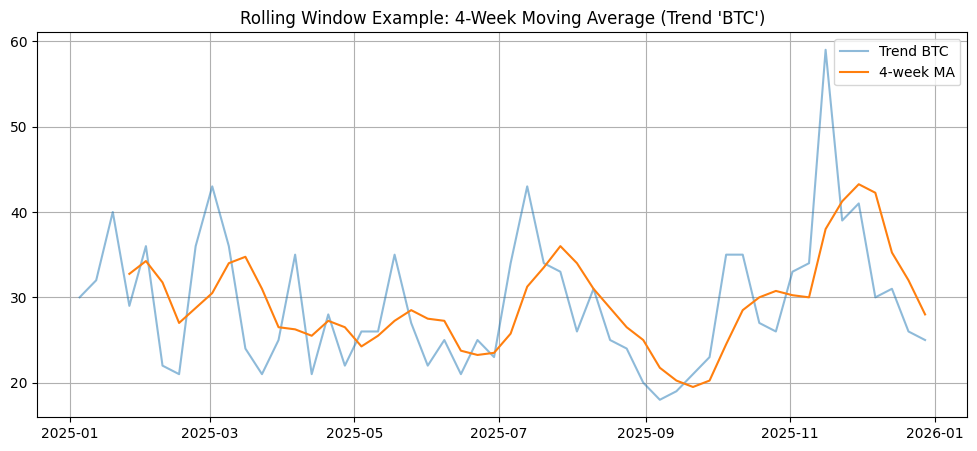

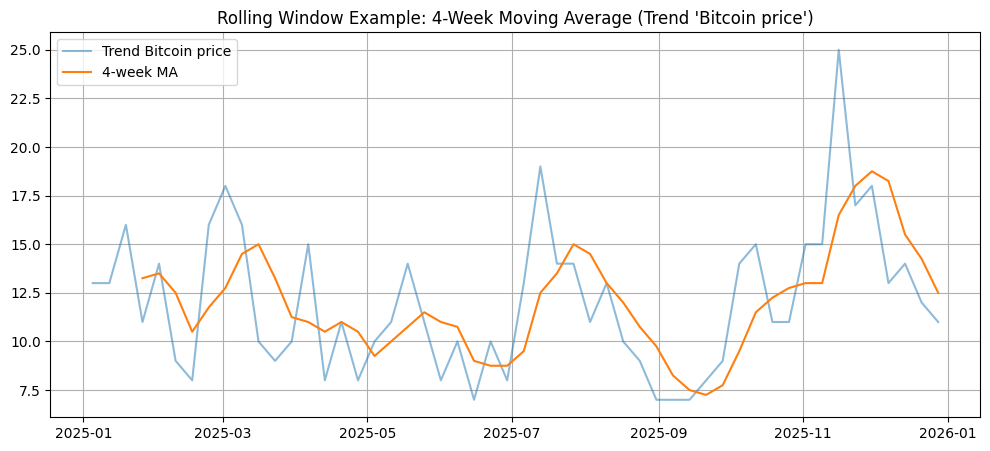

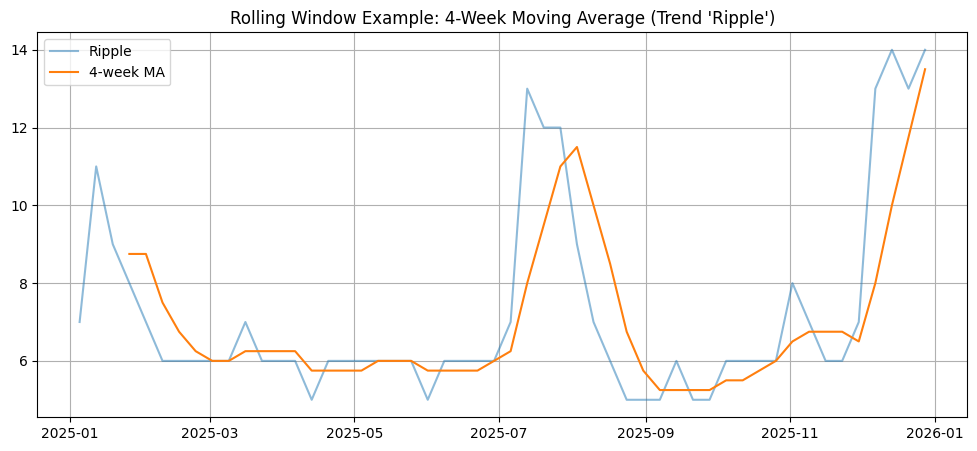

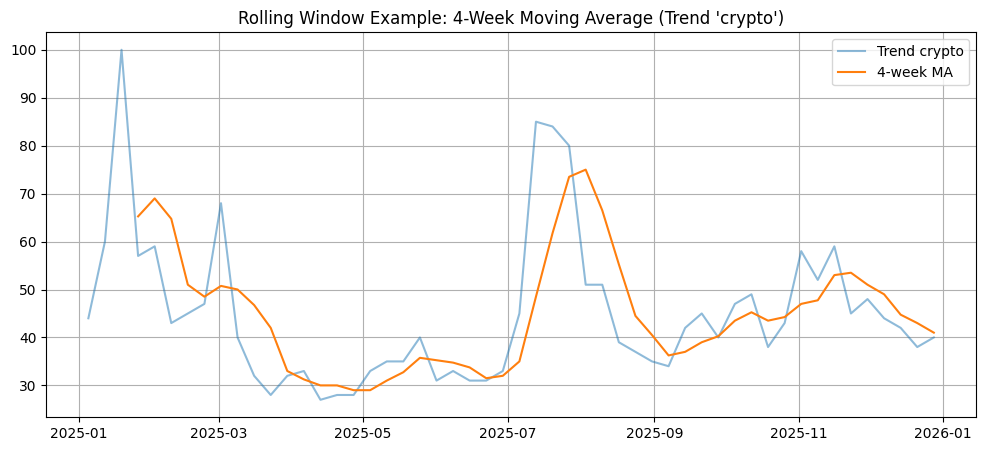

In [ ]:
window = 4

df_roll = df.copy()
df_roll["Buy Bitcoin_ma4"] = df_roll["Buy Bitcoin"].rolling(window=window).mean()
df_roll["BTC_ma4"] = df_roll["BTC"].rolling(window=window).mean()
df_roll["BTC price_ma4"] = df_roll["BTC price"].rolling(window=window).mean()
df_roll["Ripple_ma4"] = df_roll["Ripple"].rolling(window=window).mean()
df_roll["crypto_ma4"] = df_roll["crypto"].rolling(window=window).mean()




plt.plot(df_roll.index, df_roll["Buy Bitcoin"], alpha=0.5, label="Trend Bitcoin")
plt.plot(df_roll.index, df_roll["Buy Bitcoin_ma4"], label="4-week MA")
plt.title("Rolling Window Example: 4-Week Moving Average (Trend 'Buy crypto')")
plt.legend()
plt.grid(True)
plt.show()


plt.plot(df_roll.index, df_roll["BTC"], alpha=0.5, label="Trend BTC")
plt.plot(df_roll.index, df_roll["BTC_ma4"], label="4-week MA")
plt.title("Rolling Window Example: 4-Week Moving Average (Trend 'BTC')")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(df_roll.index, df_roll["BTC price"], alpha=0.5, label="Trend Bitcoin price")
plt.plot(df_roll.index, df_roll["BTC price_ma4"], label="4-week MA")
plt.title("Rolling Window Example: 4-Week Moving Average (Trend 'Bitcoin price')")
plt.legend()
plt.grid(True)
plt.show()


plt.plot(df_roll.index, df_roll["Ripple"], alpha=0.5, label="Ripple")
plt.plot(df_roll.index, df_roll["Ripple_ma4"], label="4-week MA")
plt.title("Rolling Window Example: 4-Week Moving Average (Trend 'Ripple')")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(df_roll.index, df_roll["crypto"], alpha=0.5, label="Trend crypto")
plt.plot(df_roll.index, df_roll["crypto_ma4"], label="4-week MA")
plt.title("Rolling Window Example: 4-Week Moving Average (Trend 'crypto')")
plt.legend()
plt.grid(True)
plt.show()

Why rolling window of 4

A rolling window of 4 weeks was selected to smooth short-term fluctuations in the Bitcoin data and to better capture underlying market trends in both Bitcoin returns and Google Trends variables. Since the dataset is sampled at a weekly frequency, a 4-week window corresponds to approximately one month of information, which is a meaningful short-term horizon in financial market analysis.

Bitcoin markets are highly volatile and often experience sharp, short-lived fluctuations driven by speculative trading and external news events. Applying a rolling window helps reduce this noise by averaging observations over recent periods, thereby producing a more stable representation of market behaviour. This improves the reliability of the modelling process by reducing the influence of random weekly shocks that do not reflect persistent trends.

Furthermore, a 4-week window provides a balance between responsiveness and smoothness. Smaller windows may retain excessive noise, while larger windows may over-smooth the data and delay the detection of important signals. Therefore, a 4-week rolling window was considered appropriate for capturing short-term Bitcoin market dynamics while maintaining sufficient signal clarity for predictive modelling

##Check for stationerity

Why does stationerity matters

That is beacause stationary series have constant mean, variance, and autocorrelation over time.This stability makes the series predictable and allows models to learn consistent patterns. And If a series is non-stationary (e.g., trends, seasonality, changing variance), the model may produce misleading results because the statistical relationships shift over time.

In [ ]:

def check_stationarity(timeseries, name):
    # ADF Test
    print(f"Results for Augmented Dickey-Fuller Test on '{name}':")
    adf_test = adfuller(timeseries.dropna())
    print(f"ADF Statistic: {adf_test[0]}")
    print(f"P-value: {adf_test[1]}")
    print("Critical Values:")
    for key, value in adf_test[4].items():
        print(f"\t{key}: {value}")
    if adf_test[1] <= 0.05:
        print(f"Result: '{name}' is likely stationary (p-value < 0.05).")
    else:
        print(f"Result: '{name}' is likely non-stationary (p-value >= 0.05).")
    print("-" * 40)

if not df.empty:
    print("--- Checking stationarity for trends_w ---")
    for col in df.columns:
        check_stationarity(df[col], col)
else:
    print("Bitcoin_data is empty. Cannot perform stationarity test.")

--- Checking stationarity for trends_w ---
Results for Augmented Dickey-Fuller Test on 'price_w':
ADF Statistic: -1.3387623020232002
P-value: 0.6112573106514126
Critical Values:
	1%: -3.5656240522121956
	5%: -2.920142229157715
	10%: -2.598014675124952
Result: 'price_w' is likely non-stationary (p-value >= 0.05).
----------------------------------------
Results for Augmented Dickey-Fuller Test on 'log_return_w':
ADF Statistic: -7.162648607326168
P-value: 2.9407492613753244e-10
Critical Values:
	1%: -3.5656240522121956
	5%: -2.920142229157715
	10%: -2.598014675124952
Result: 'log_return_w' is likely stationary (p-value < 0.05).
----------------------------------------
Results for Augmented Dickey-Fuller Test on 'volume_w':
ADF Statistic: -1.785861663430848
P-value: 0.3875032319985088
Critical Values:
	1%: -3.5745892596209488
	5%: -2.9239543084490744
	10%: -2.6000391840277777
Result: 'volume_w' is likely non-stationary (p-value >= 0.05).
----------------------------------------
Results fo

##Diffrencing and Re-checking for stationerity

In [ ]:
df_diff = df.copy()
df_diff["price_w"] = df_diff["price_w"].diff()
df_diff["Ripple"] = df_diff["Ripple"].diff()
df_diff["Buy Bitcoin"] = df_diff["Buy Bitcoin"].diff(periods=2)
df_diff["volume_w"] = df_diff["volume_w"].diff(periods=3)



In [ ]:
##Chcek for stationerity again after Diffrencing

def check_stationarity(timeseries, name):
    # ADF Test
    print(f"Results for Augmented Dickey-Fuller Test on '{name}':")
    adf_test = adfuller(timeseries.dropna())
    print(f"ADF Statistic: {adf_test[0]}")
    print(f"P-value: {adf_test[1]}")
    print("Critical Values:")
    for key, value in adf_test[4].items():
        print(f"\t{key}: {value}")
    if adf_test[1] <= 0.05:
        print(f"Result: '{name}' is likely stationary (p-value < 0.05).")
    else:
        print(f"Result: '{name}' is likely non-stationary (p-value >= 0.05).")
    print("-" * 40)

if not df.empty:
    print("--- Checking stationarity for trends_w ---")
    for col in df_diff.columns:
        check_stationarity(df_diff[col], col)
else:
    print("Bitcoin_data is empty. Cannot perform stationarity test.")

--- Checking stationarity for trends_w ---
Results for Augmented Dickey-Fuller Test on 'price_w':
ADF Statistic: -7.185102690031023
P-value: 2.589112653666199e-10
Critical Values:
	1%: -3.568485864
	5%: -2.92135992
	10%: -2.5986616
Result: 'price_w' is likely stationary (p-value < 0.05).
----------------------------------------
Results for Augmented Dickey-Fuller Test on 'log_return_w':
ADF Statistic: -7.162648607326168
P-value: 2.9407492613753244e-10
Critical Values:
	1%: -3.5656240522121956
	5%: -2.920142229157715
	10%: -2.598014675124952
Result: 'log_return_w' is likely stationary (p-value < 0.05).
----------------------------------------
Results for Augmented Dickey-Fuller Test on 'volume_w':
ADF Statistic: -3.177550392264971
P-value: 0.021321483922095107
Critical Values:
	1%: -3.6055648906249997
	5%: -2.937069375
	10%: -2.606985625
Result: 'volume_w' is likely stationary (p-value < 0.05).
----------------------------------------
Results for Augmented Dickey-Fuller Test on 'Buy Bit

In [ ]:
#Verifying stationerity by making use of kpss
def check_kpss(timeseries, name):

    print(f"Results for KPSS Test on '{name}':")

    kpss_test = kpss(timeseries.dropna(), regression='c', nlags='auto')

    print(f"KPSS Statistic: {kpss_test[0]}")
    print(f"P-value: {kpss_test[1]}")
    print("Critical Values:")

    for key, value in kpss_test[3].items():
        print(f"\t{key}: {value}")

    if kpss_test[1] > 0.05:
        print(f"Result: '{name}' is likely stationary (p-value > 0.05).")
    else:
        print(f"Result: '{name}' is likely non-stationary (p-value <= 0.05).")

    print("-" * 40)


# RUN KPSS on differenced data
if not df_diff.empty:
    print("--- Checking stationarity for differenced data (KPSS) ---\n")

    for col in df_diff.columns:
        check_kpss(df_diff[col], col)

else:
    print("Differenced data is empty. Cannot perform stationarity test.")

--- Checking stationarity for differenced data (KPSS) ---

Results for KPSS Test on 'price_w':
KPSS Statistic: 0.18462651541669522
P-value: 0.1
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739
Result: 'price_w' is likely stationary (p-value > 0.05).
----------------------------------------
Results for KPSS Test on 'log_return_w':
KPSS Statistic: 0.19541395055125846
P-value: 0.1
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739
Result: 'log_return_w' is likely stationary (p-value > 0.05).
----------------------------------------
Results for KPSS Test on 'volume_w':
KPSS Statistic: 0.11004583068884774
P-value: 0.1
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739
Result: 'volume_w' is likely stationary (p-value > 0.05).
----------------------------------------
Results for KPSS Test on 'Buy Bitcoin':
KPSS Statistic: 0.045844753581217354
P-value: 0.1
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739
Result: 'Buy Bitcoin' is likely st

/tmp/ipykernel_21062/2572765796.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(timeseries.dropna(), regression='c', nlags='auto')
/tmp/ipykernel_21062/2572765796.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(timeseries.dropna(), regression='c', nlags='auto')
/tmp/ipykernel_21062/2572765796.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(timeseries.dropna(), regression='c', nlags='auto')
/tmp/ipykernel_21062/2572765796.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greate

##STL Decomposition

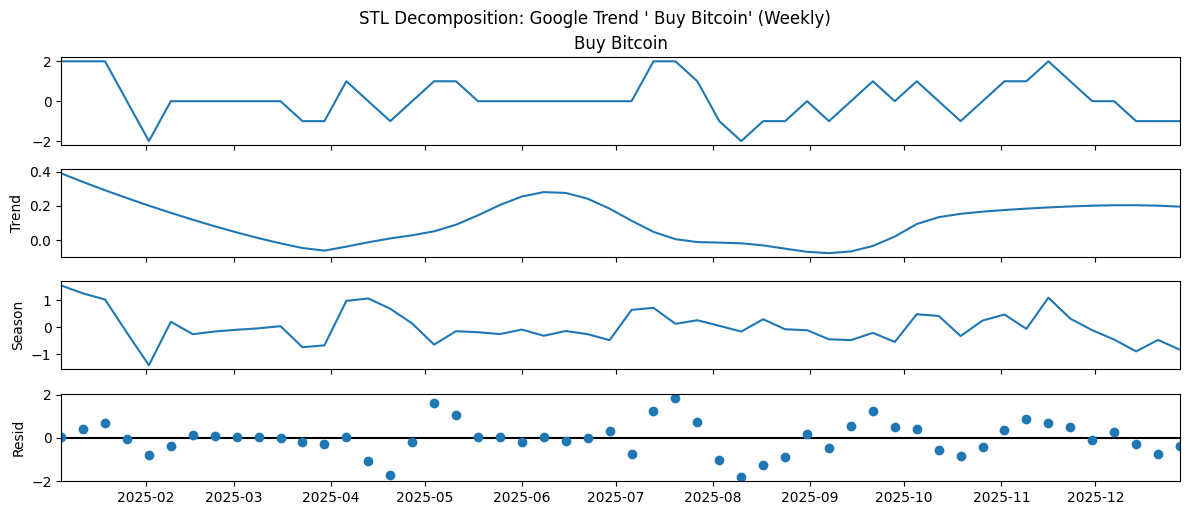

In [ ]:



series = df_diff["Buy Bitcoin"].bfill().ffill()
stl = STL(series, period=13)
res = stl.fit()

res.plot()
plt.suptitle("STL Decomposition: Google Trend ' Buy Bitcoin' (Weekly)", y=1.02)
plt.show()

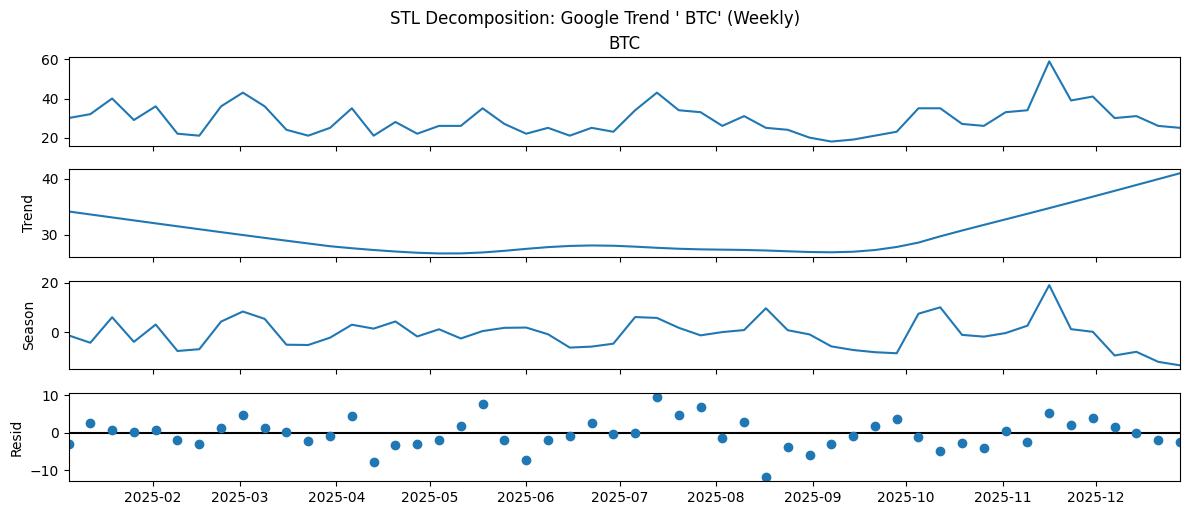

In [ ]:
series = df_diff["BTC"].bfill().ffill()
stl = STL(series, period=13)
res = stl.fit()

res.plot()
plt.suptitle("STL Decomposition: Google Trend ' BTC' (Weekly)", y=1.02)
plt.show()

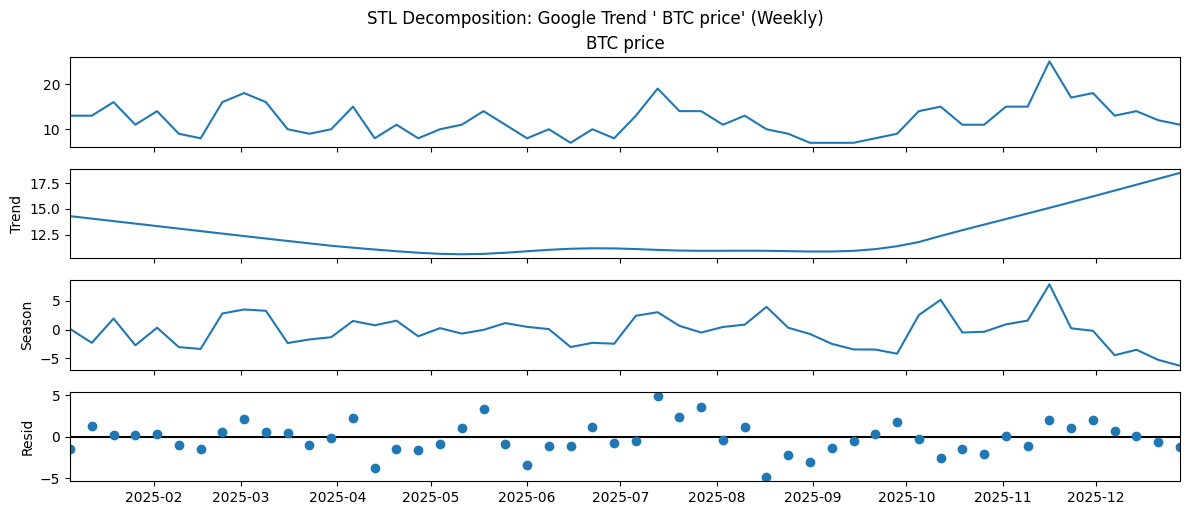

In [ ]:
series = df_diff["BTC price"].bfill().ffill()
stl = STL(series, period=13)
res = stl.fit()

res.plot()
plt.suptitle("STL Decomposition: Google Trend ' BTC price' (Weekly)", y=1.02)
plt.show()

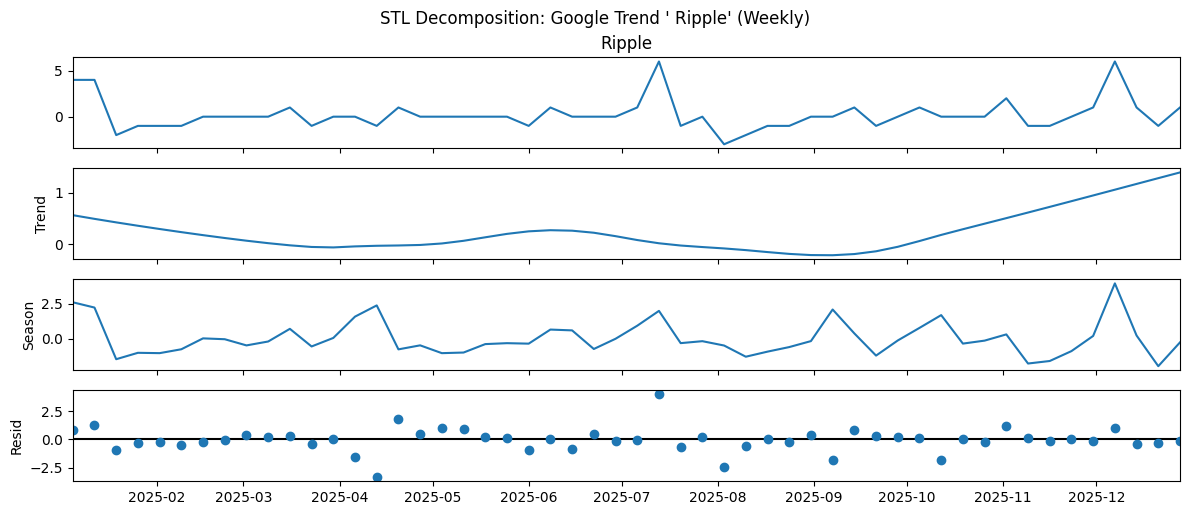

In [ ]:
series = df_diff["Ripple"].bfill().ffill()
stl = STL(series, period=13)
res = stl.fit()

res.plot()
plt.suptitle("STL Decomposition: Google Trend ' Ripple' (Weekly)", y=1.02)
plt.show()

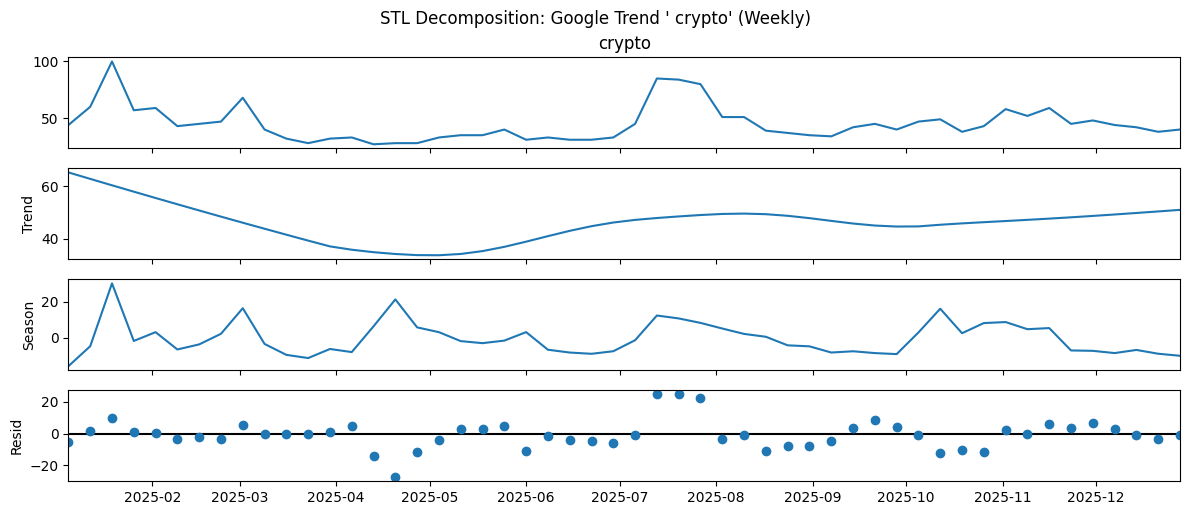

In [ ]:
series = df_diff["crypto"].bfill().ffill()
stl = STL(series, period=13)
res = stl.fit()

res.plot()
plt.suptitle("STL Decomposition: Google Trend ' crypto' (Weekly)", y=1.02)
plt.show()

##Autocorrelation(ACF) and Partial Autocorrelation (PACF)









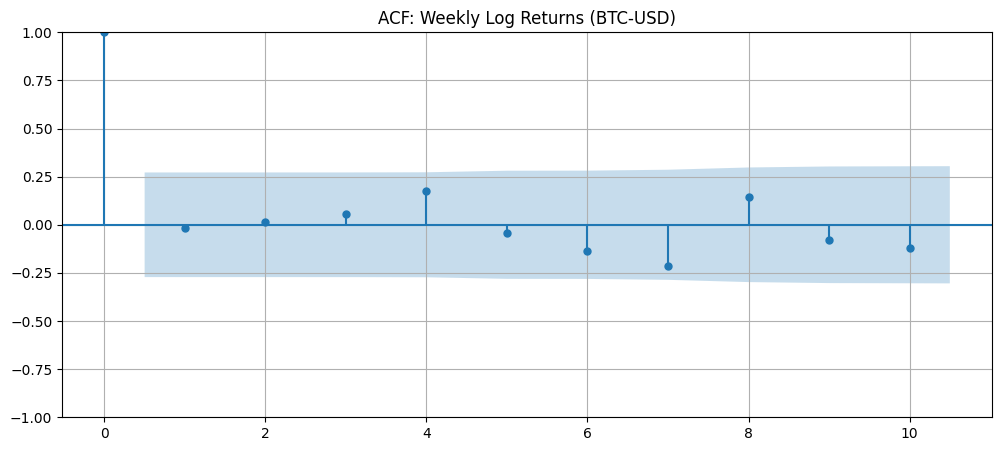

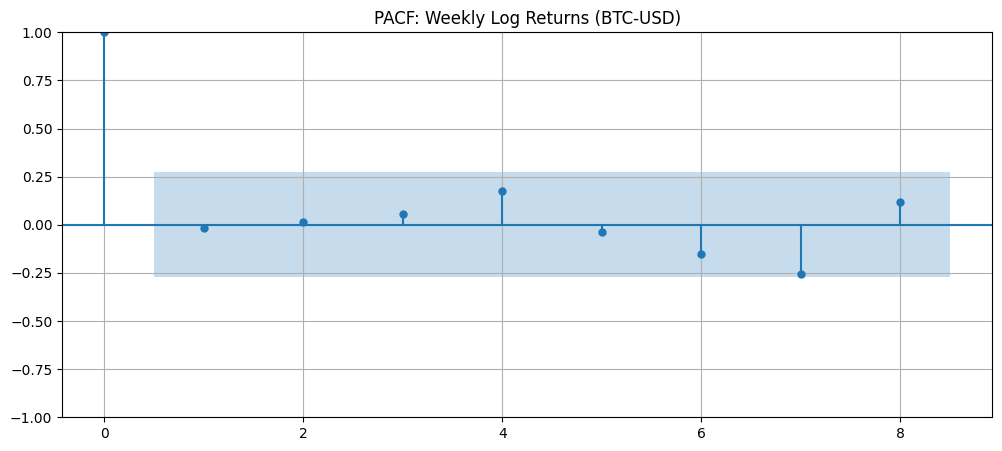

In [ ]:
series_r = df["log_return_w"].dropna()

plot_acf(series_r, lags=10)
plt.title("ACF: Weekly Log Returns (BTC-USD)")
plt.grid(True)
plt.show()

plot_pacf(series_r, lags=8, method="ywm")
plt.title("PACF: Weekly Log Returns (BTC-USD)")
plt.grid(True)
plt.show()


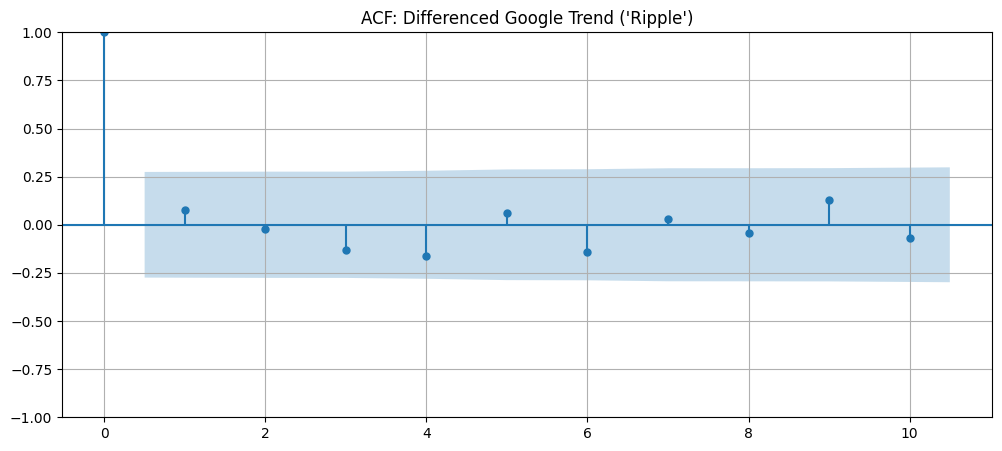

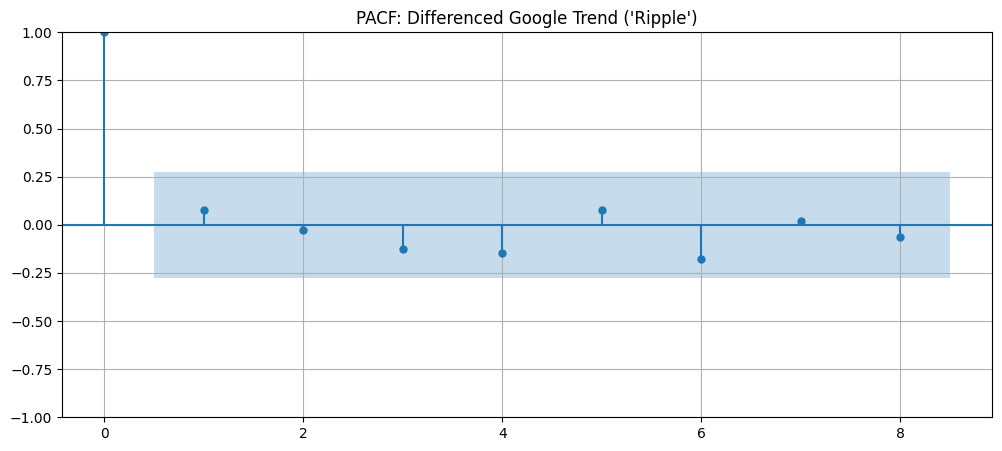

In [ ]:
# ACF/PACF for differenced Google Trends
trend_d = df_diff["Ripple"].dropna()

plot_acf(trend_d, lags=10)
plt.title("ACF: Differenced Google Trend ('Ripple')")
plt.grid(True)
plt.show()

plot_pacf(trend_d, lags=8, method="ywm")
plt.title("PACF: Differenced Google Trend ('Ripple')")
plt.grid(True)
plt.show()

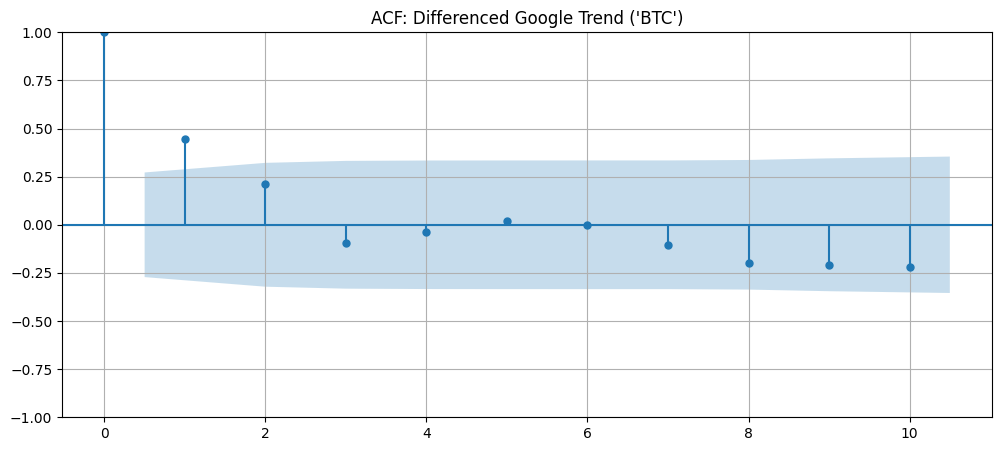

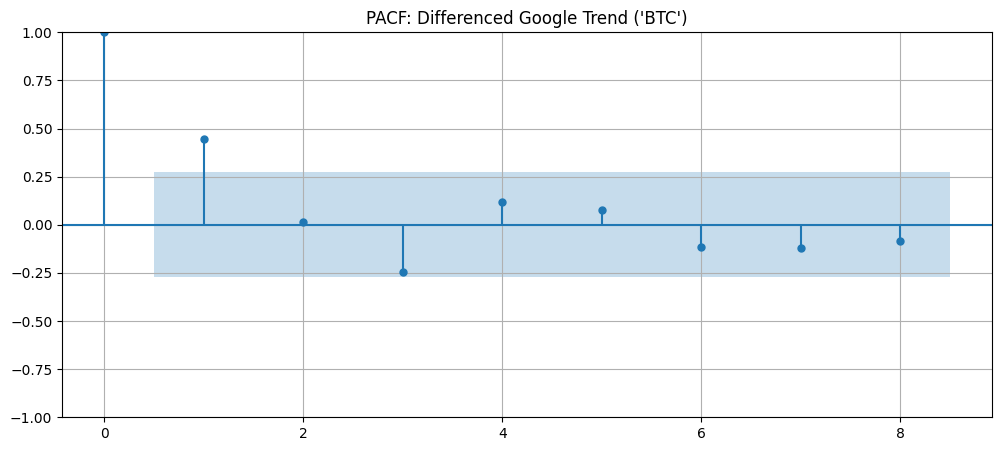

In [ ]:
# ACF/PACF for differenced Google Trends
trend_d = df_diff["BTC"].dropna()

plot_acf(trend_d, lags=10)
plt.title("ACF: Differenced Google Trend ('BTC')")
plt.grid(True)
plt.show()

plot_pacf(trend_d, lags=8, method="ywm")
plt.title("PACF: Differenced Google Trend ('BTC')")
plt.grid(True)
plt.show()

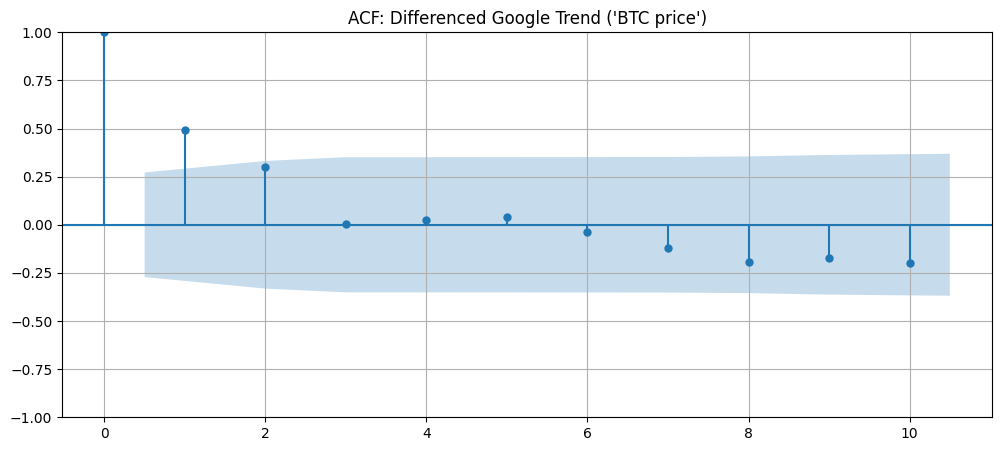

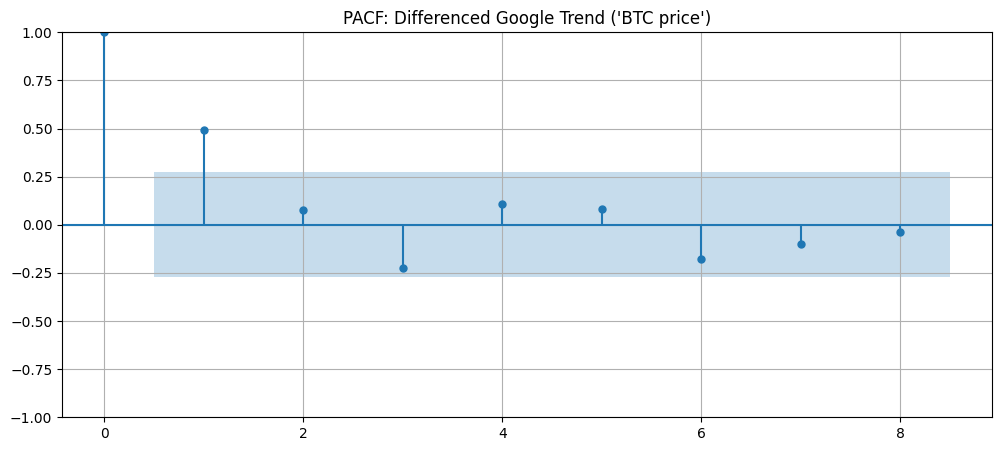

In [ ]:
# ACF/PACF for differenced Google Trends
trend_d = df_diff["BTC price"].dropna()

plot_acf(trend_d, lags=10)
plt.title("ACF: Differenced Google Trend ('BTC price')")
plt.grid(True)
plt.show()

plot_pacf(trend_d, lags=8, method="ywm")
plt.title("PACF: Differenced Google Trend ('BTC price')")
plt.grid(True)
plt.show()

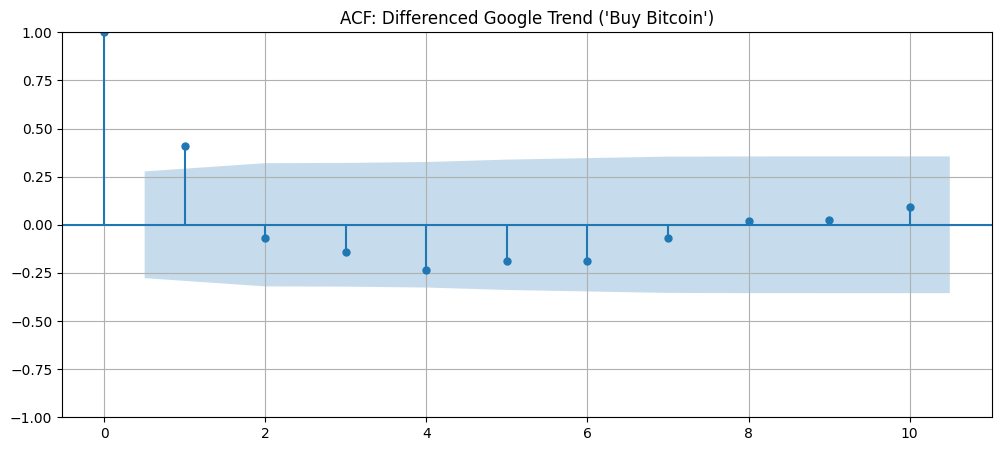

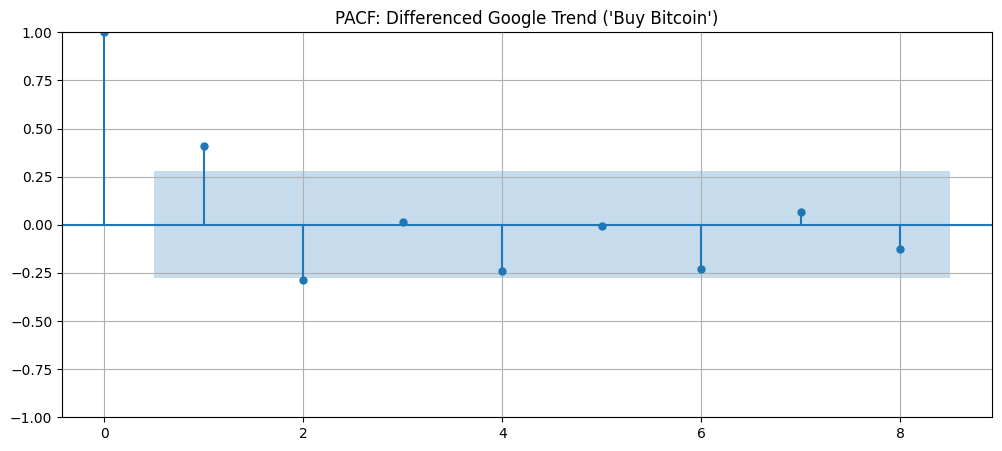

In [ ]:
# ACF/PACF for differenced Google Trends
trend_d = df_diff["Buy Bitcoin"].dropna()

plot_acf(trend_d, lags=10)
plt.title("ACF: Differenced Google Trend ('Buy Bitcoin')")
plt.grid(True)
plt.show()

plot_pacf(trend_d, lags=8, method="ywm")
plt.title("PACF: Differenced Google Trend ('Buy Bitcoin')")
plt.grid(True)
plt.show()

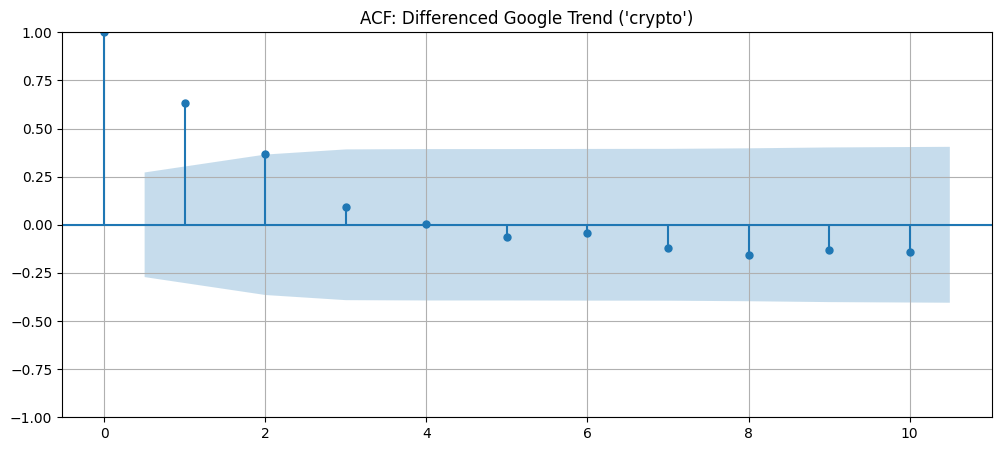

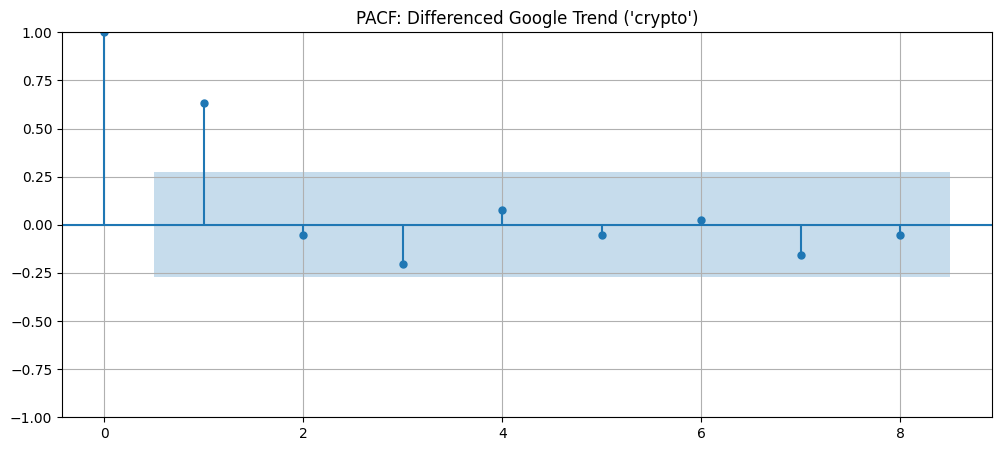

In [ ]:
# ACF/PACF for differenced Google Trends
trend_d = df_diff["crypto"].dropna()

plot_acf(trend_d, lags=10)
plt.title("ACF: Differenced Google Trend ('crypto')")
plt.grid(True)
plt.show()

plot_pacf(trend_d, lags=8, method="ywm")
plt.title("PACF: Differenced Google Trend ('crypto')")
plt.grid(True)
plt.show()

##Lead-lag analysis (Cross-Correlation)

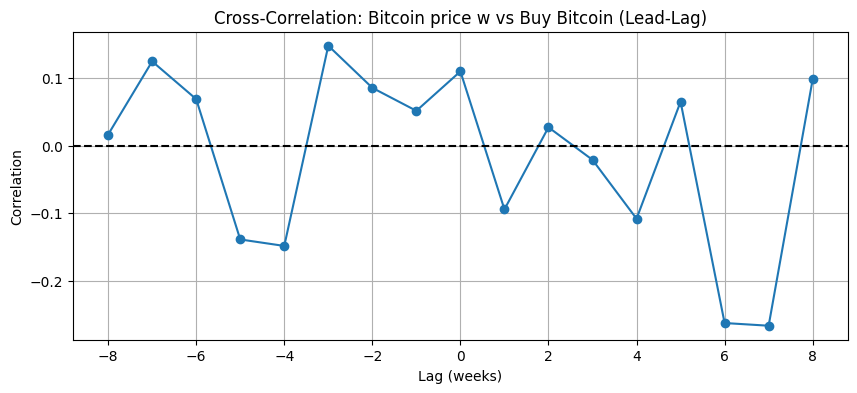

Buy Bitcoin vs price w: Best lag = 7 (leads), correlation = -0.266



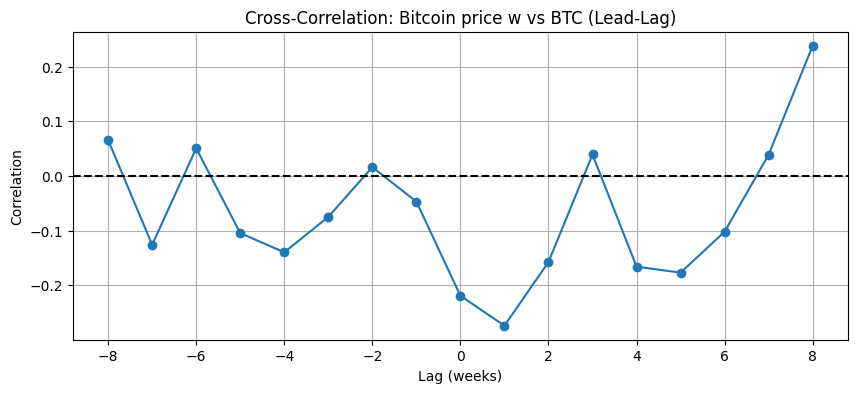

BTC vs price w: Best lag = 1 (leads), correlation = -0.274



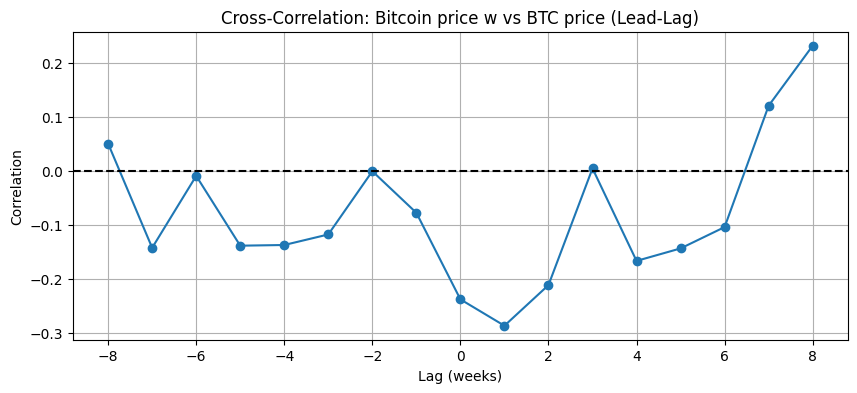

BTC price vs price w: Best lag = 1 (leads), correlation = -0.287



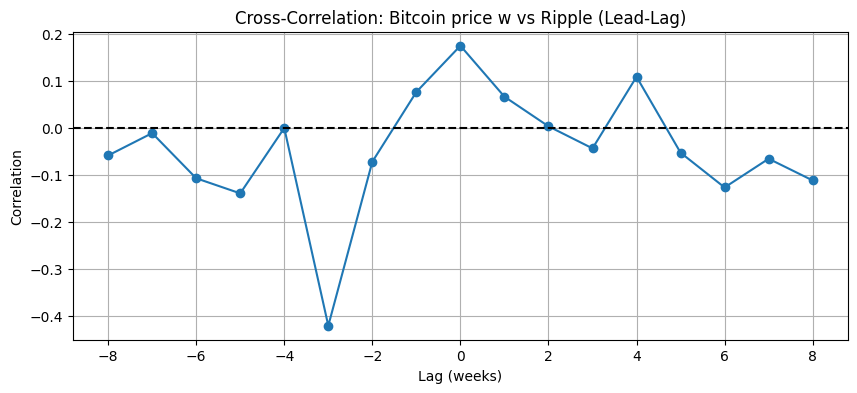

Ripple vs price w: Best lag = -3 (lags), correlation = -0.421



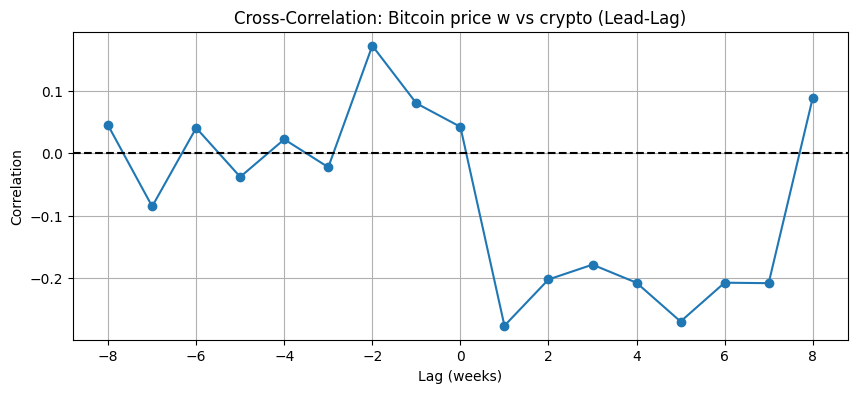

crypto vs price w: Best lag = 1 (leads), correlation = -0.276



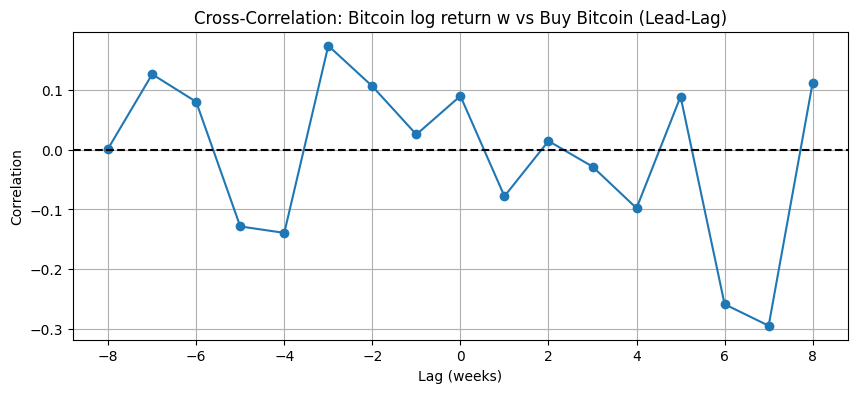

Buy Bitcoin vs log return w: Best lag = 7 (leads), correlation = -0.294



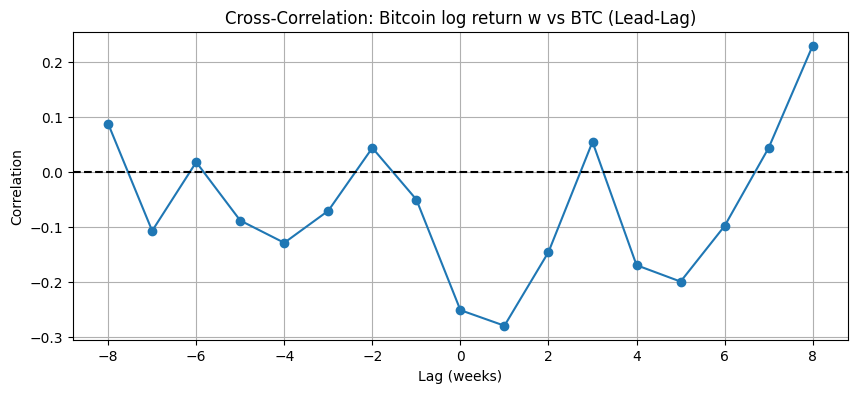

BTC vs log return w: Best lag = 1 (leads), correlation = -0.279



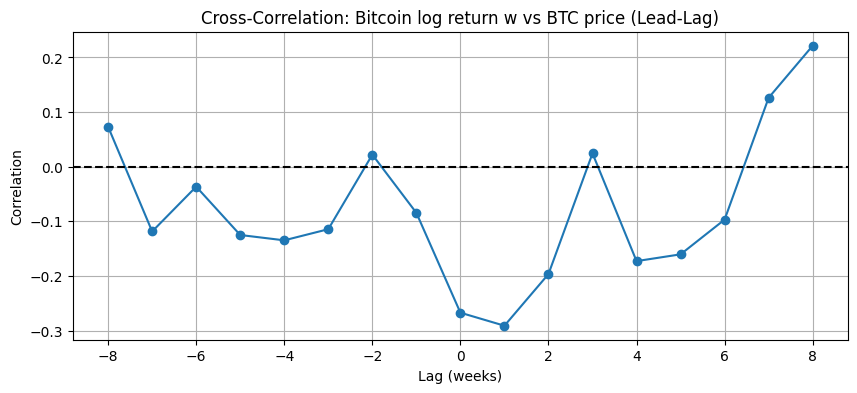

BTC price vs log return w: Best lag = 1 (leads), correlation = -0.291



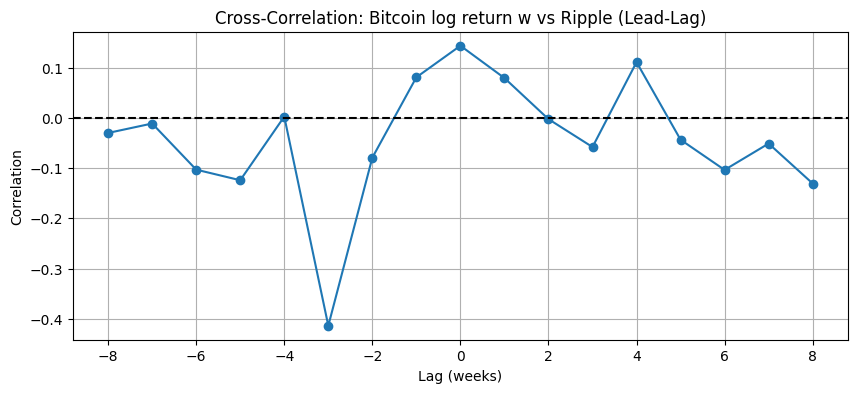

Ripple vs log return w: Best lag = -3 (lags), correlation = -0.413



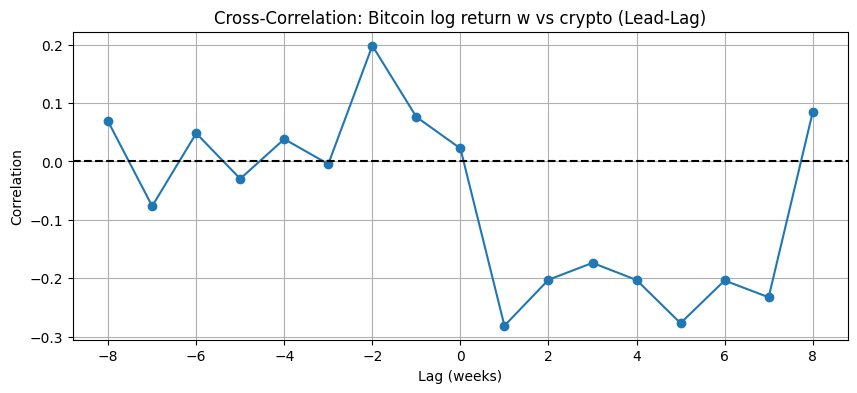

crypto vs log return w: Best lag = 1 (leads), correlation = -0.281



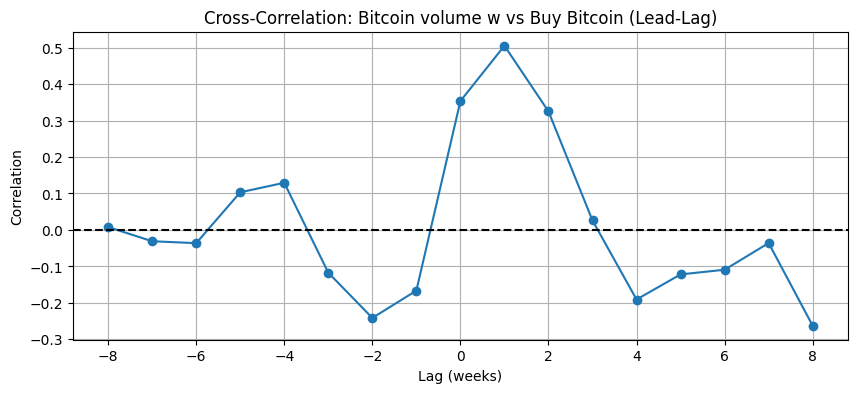

Buy Bitcoin vs volume w: Best lag = 1 (leads), correlation = 0.505



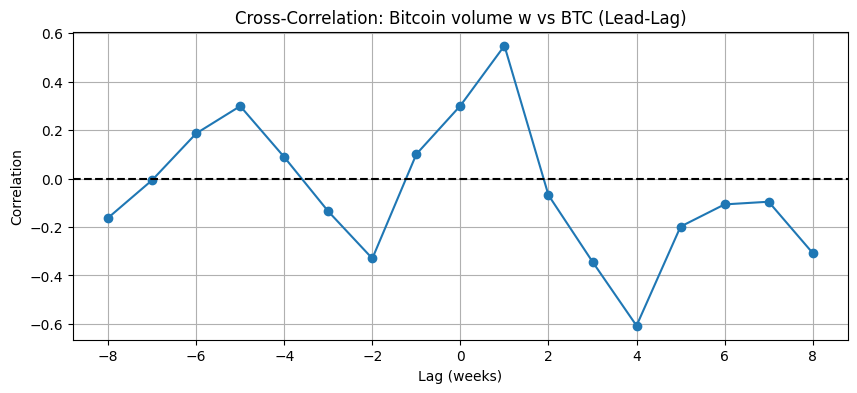

BTC vs volume w: Best lag = 4 (leads), correlation = -0.607



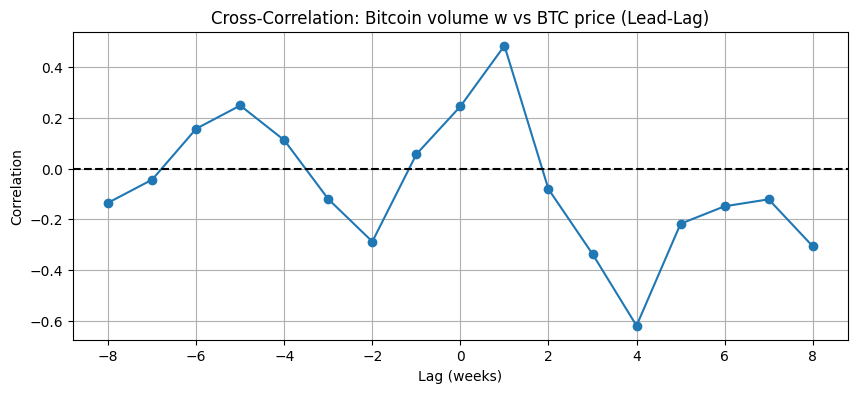

BTC price vs volume w: Best lag = 4 (leads), correlation = -0.619



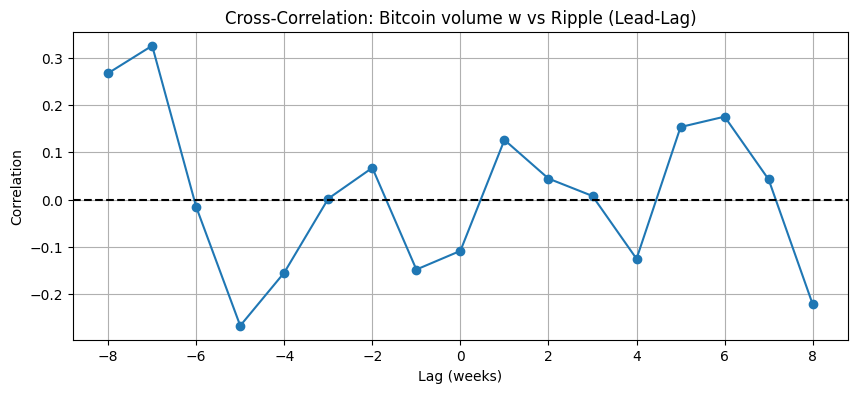

Ripple vs volume w: Best lag = -7 (lags), correlation = 0.326



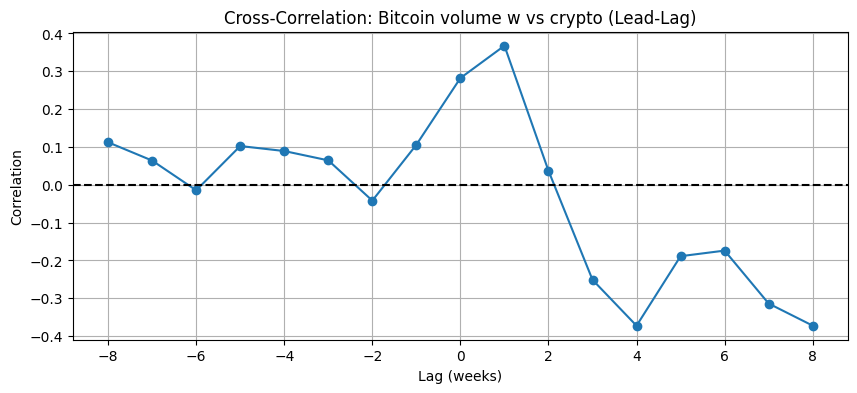

crypto vs volume w: Best lag = 4 (leads), correlation = -0.372



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def cross_corr(x, y, max_lag=8):
    lags = range(-max_lag, max_lag+1)
    corrs = [x.corr(y.shift(lag)) for lag in lags]
    return pd.Series(corrs, index=lags)

# Bitcoin variables (using actual column names from 'df_diff' for stationary series)
btc_vars = ['price_w', 'log_return_w','volume_w']

# Google Trends variables (using actual column names from 'df_diff' for stationary series)
trend_vars = ["Buy Bitcoin", "BTC", "BTC price","Ripple", "crypto"]

max_lag = 8

for btc in btc_vars:
    for trend in trend_vars:
        # Access both variables from the 'df_diff' DataFrame which contains stationary series
        # Drop NaNs that result from differencing or initial data loading
        series_x = df_diff[btc].dropna()
        series_y = df_diff[trend].dropna()

        # Ensure both series have overlapping indices for correlation calculation
        common_index = series_x.index.intersection(series_y.index)
        if common_index.empty or len(common_index) < max_lag:
            print(f"Skipping cross-correlation for {btc} and {trend} due to insufficient overlapping data after dropping NaNs.")
            continue

        series_x = series_x.loc[common_index]
        series_y = series_y.loc[common_index]

        cc = cross_corr(series_x, series_y, max_lag=max_lag)

        # Plot
        plt.figure(figsize=(10,4))
        plt.plot(cc.index, cc.values, marker='o')
        plt.axhline(0, color='black', linestyle='--')
        plt.xlabel("Lag (weeks)")
        plt.ylabel("Correlation")
        plt.title(f"Cross-Correlation: Bitcoin {btc.replace('_', ' ')} vs {trend.replace('_', ' ')} (Lead-Lag)")
        plt.grid(True)
        plt.show()


         # Strongest lead/lag
        best_lag = cc.abs().idxmax()
        best_corr = cc.loc[best_lag]
        #where best_lag>0 or <0 else search again so it is equal to 0
        if best_lag != 0:
               direction = "leads" if best_lag > 0 else "lags" if best_lag < 0 else "simultaneous"
        print(f"{trend.replace('trend_', '').replace('_', ' ')} vs {btc.replace('_', ' ')}: Best lag = {best_lag} ({direction}), correlation = {best_corr:.3f}\n")


Why Lag = 8:

Financial markets do not react instantly to information; instead, information such as investor attention (Google Trends) may take time to be incorporated into prices

Because our data is weekly and 1 Lag= 1week, 8 Lags=8 weeks ≈ 2 months. This is reasonable beacause market attention effects persist for serveral weeks rather than days. Prior studies in financial econometrics and behavioural finance commonly use lag windows between 1 and 8 weeks to capture delayed investor reaction and information diffusion effects.

Therefore: The lag range was chosen to ensure that both short-term and medium-term relationships are captured without introducing excessive noise from long-horizon dependencies.



Since forr:Lead–Lag Relationship

H₀: There is no lead–lag relationship between Google Trends and Bitcoin market activity

H₁: A lead–lag relationship exists


We Reject null hypothesis and conclude that, A lead-lag relationahip exists.Based on the results we got

##Granger Casuality

In [ ]:
# testing to examine whether internet attention helps explain Bitcoin returns and trading volume
btc_vars = ['log_return_w', 'volume_w']

# Google Trends variables (using actual column names from the 'df_diff' DataFrame)

trend_vars = ["Buy Bitcoin", "BTC", "BTC price","Ripple", "crypto"]


max_lag = 12  # maximum lag (weeks) to test

significance_level = 0.05  # threshold for p-value

results = []

for btc in btc_vars:
    for trend in trend_vars:
        # Ensure both variables are accessed from the 'df_diff' DataFrame
        # Drop NaNs that result from differencing, as Granger causality tests require complete series.
        test_data = df_diff[[btc, trend]].dropna()

        # Skip test if there's insufficient data after dropping NaNs
        if test_data.empty or len(test_data) < max_lag + 2:
            print(f"Skipping Granger test for {btc} and {trend} due to insufficient data.")
            results.append({
                'Bitcoin_variable': btc,
                'Trend_variable': trend,
                'Best_lag': None,
                'Min_p_value': None,
                'Significance': "Insufficient Data"
            })
            continue

        # run granger causality test for lags 1 to max_lag
        try:
            gc_test = grangercausalitytests(test_data, maxlag=max_lag, verbose=False)

            # Find the lag with the smallest p-value for the F-test
            min_p = 1
            best_lag = None
            for lag in range(1, max_lag+1):
                # Ensure the lag result exists before accessing
                if lag in gc_test and 'ssr_ftest' in gc_test[lag][0]:
                    p_value = gc_test[lag][0]['ssr_ftest'][1]
                    if p_value < min_p:
                        min_p = p_value
                        best_lag = lag

            # Determine if significant
            if best_lag is not None and min_p < significance_level:
                significance = "Significant"
            elif best_lag is not None:
                significance = "Not significant"
            else:
                significance = "No significant lag found"

            results.append({
                'Bitcoin_variable': btc,
                'Trend_variable': trend,
                'Best_lag': best_lag,
                'Min_p_value': min_p,
                'Significance': significance
            })
        except ValueError as e:
            print(f"Error running Granger test for {btc} and {trend}: {e}")
            results.append({
                'Bitcoin_variable': btc,
                'Trend_variable': trend,
                'Best_lag': None,
                'Min_p_value': None,
                'Significance': f"Error: {e}"
            })

# Convert results to DataFrame for easy viewing
granger_results = pd.DataFrame(results)
print(granger_results)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print resul

  Bitcoin_variable Trend_variable  Best_lag   Min_p_value     Significance
0     log_return_w    Buy Bitcoin         6  5.385201e-02  Not significant
1     log_return_w            BTC         1  3.920492e-02      Significant
2     log_return_w      BTC price         1  3.023683e-02      Significant
3     log_return_w         Ripple         1  5.815712e-01  Not significant
4     log_return_w         crypto         4  4.585748e-02      Significant
5         volume_w    Buy Bitcoin         1  1.976884e-03      Significant
6         volume_w            BTC         2  2.696347e-08      Significant
7         volume_w      BTC price         2  1.765894e-07      Significant
8         volume_w         Ripple         7  2.200617e-02      Significant
9         volume_w         crypto         7  1.011503e-03      Significant


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


For:Granger Causality

H₀: Google Trends does not Granger-cause Bitcoin returns or trading volume

H₁: Google Trends Granger-causes Bitcoin returns or trading volume

We therefore Reject null hypothesis and  conclude that Google Trends Granger-causes Bitcoin returns or trading volume due to majority of our results being significant

Interpretation


The Granger causality tests show which variables have predictive power over Bitcoin’s weekly returns (log_return_w) and weekly trading volume (volume_w).

Bitcoin Returns (log_return_w):

The variables BTC, BTC price, and crypto are statistically significant predictors of Bitcoin returns. This means past values of these variables help forecast future returns.

The variables Buy Bitcoin and Ripple are not significant, suggesting they do not provide useful information for predicting returns.

Bitcoin Volume (volume_w):

The variables Buy Bitcoin, BTC, BTC price, Ripple, and crypto are all statistically significant predictors of Bitcoin trading volume. This indicates that both Bitcoin-specific factors and broader crypto sentiment strongly influence trading activity.

The significance levels are very strong (extremely low p-values), especially for BTC and BTC price, showing that these are dominant drivers of volume.

Lag Structure:

Returns are influenced quickly, with significant predictors at short lags (1–4 weeks).

Volume responds both immediately (1–2 weeks) and with longer delays (up to 7 weeks), especially to Ripple and general crypto sentiment.

Returns: Driven mainly by Bitcoin-specific trends and the broader crypto market, but not by Ripple or “Buy Bitcoin” sentiment.

Volume: Much more sensitive — strongly affected by Bitcoin price, sentiment, and even Ripple trends.

Practical Meaning: Traders talk more (“Buy Bitcoin” sentiment boosts volume), but this doesn’t necessarily move prices. Price and BTC trends, however, do affect both returns and volume.

##Machine Learning




In [ ]:
df.head()

,price_w,log_return_w,volume_w,Buy Bitcoin,BTC,BTC price,Ripple,crypto
2025-01-05,98314.960938,0.040426,149008707396,2.0,30.0,13.0,7.0,44.0
2025-01-12,94488.437500,-0.039699,338967010865,2.0,32.0,13.0,11.0,60.0
2025-01-19,101089.609375,0.067530,437782936416,4.0,40.0,16.0,9.0,100.0
2025-01-26,102682.500000,0.015634,471816874719,2.0,29.0,11.0,8.0,57.0
2025-02-02,97688.976562,-0.049853,362117614322,2.0,36.0,14.0,7.0,59.0


In [ ]:
df['target'] = df['log_return_w'].shift(-1)

# Drop last row (because of shift)
df = df.dropna()

In [ ]:
features = [
    'log_return_w', 'volume_w',

    # Google Trends
    'Buy Bitcoin',
    'BTC',
    'BTC price',
    'Ripple',
    'crypto'
]


X = df[features]
y = df['target']

In [ ]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [ ]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1))

In [ ]:
def create_sequences(X, y, window=4):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

window_size = 4  # good for weekly data

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, window_size)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, window_size)


In [ ]:

# BUILD LSTM MODEL

model = Sequential()

model.add(LSTM(32, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
model.add(Dropout(0.3))

model.add(LSTM(16))
model.add(Dropout(0.3))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')


# 9. EARLY STOPPING (to prevent overfitting)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# TRAIN MODEL

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=30,
    batch_size=16,
    validation_data=(X_test_seq, y_test_seq),
    callbacks=[early_stop],
    verbose=1
)

#  PREDICT

preds_scaled = model.predict(X_test_seq)

# Convert back to original scale
preds = scaler_y.inverse_transform(preds_scaled)
y_actual = scaler_y.inverse_transform(y_test_seq)



Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 253ms/step - loss: 0.4826 - val_loss: 0.2286
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.4014 - val_loss: 0.1706
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.3368 - val_loss: 0.1212
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.2937 - val_loss: 0.0799
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.2337 - val_loss: 0.0476
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.1942 - val_loss: 0.0274
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1580 - val_loss: 0.0224
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1074 - val_loss: 0.0347
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.1080 - val_loss: 0.0638
Epoch 10/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0943 - val_loss: 0.1011
Epoch 11/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0699 - val_loss: 0.1349
Epoch 12/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0981 - val_loss: 0.1421


In [ ]:
# EVALUATE

rmse = np.sqrt(mean_squared_error(y_actual, preds))
mae = mean_absolute_error(y_actual, preds)
r2 = r2_score(y_actual, preds)

print("\nLSTM RESULTS (Predicting Next Week Return)")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


LSTM RESULTS (Predicting Next Week Return)
RMSE: 0.0382230906455017
MAE: 0.02913238045265208
R2: 0.3550955653090909


In [ ]:
direction_pred = (preds > 0).astype(int)
direction_actual = (y_actual > 0).astype(int)

accuracy = (direction_pred == direction_actual).mean()
print("Direction Accuracy:", accuracy)

Direction Accuracy: 0.7142857142857143


For:
Predictive Performance

H₀: Google Trends variables do not improve prediction accuracy
H₁: Google Trends variables improve prediction accuracy

Reject null hypothesis and conclude that Google Trends variables improve prediction accuracy with the following reasons taken into account:

RMSE (Root Mean Squared Error): 0.0382  
This measures the average size of prediction errors. An RMSE of ~0.038 means the model’s typical error magnitude is about 3.8% in return units.

MAE (Mean Absolute Error): 0.0291  
This is the average absolute difference between predicted and actual values. At ~2.9%, it suggests the model is fairly accurate in terms of raw error size.

R² (Coefficient of Determination): 0.355  
This indicates how much of the variance in returns is explained by the model. A value of 0.355 means the model explains about 35.5% of the variability — not very high, but not negligible either. It suggests the model captures some patterns but leaves a lot unexplained.

Direction Accuracy: 0.714 (71.4%)  
This is often the most important metric in financial forecasting. It means the model correctly predicts whether the return will be positive or negative about 71% of the time.

## Egarch model

EGARCG

In [ ]:
from arch import arch_model

# Prepare the data for EGARCH model
# Ensure returns and exogenous variables are aligned and free of NaNs
# df_diff contains the differenced (stationary) data
egarch_data = df_diff[['log_return_w', "Buy Bitcoin", "BTC", "BTC price", "Ripple", "crypto"]].dropna()

returns = egarch_data['log_return_w']
attention_vars = egarch_data[["Buy Bitcoin", "BTC", "BTC price", "Ripple", "crypto"]]

# Build EGARCH model
egarch_model = arch_model(
    returns,
    vol='EGARCH',
    p=1,
    q=1,
    mean='Zero', # Assuming mean is zero for returns
    x=attention_vars # Exogenous variables
)

egarch_fit = egarch_model.fit(disp='off', update_freq=5) # disp='off' to suppress iteration output
print(egarch_fit.summary())

                       Zero Mean - EGARCH Model Results                       
Dep. Variable:           log_return_w   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.020
Vol Model:                     EGARCH   Log-Likelihood:                82.6748
Distribution:                  Normal   AIC:                          -159.350
Method:            Maximum Likelihood   BIC:                          -153.614
                                        No. Observations:                   50
Date:                Mon, Apr 27 2026   Df Residuals:                       50
Time:                        13:32:01   Df Model:                            0
                               Volatility Model                               
                 coef    std err          t      P>|t|        95.0% Conf. Int.
------------------------------------------------------------------------------
omega         -0.0642  5.075e-06 -1.265e+04      0.0

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.002709. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


Mean Model: Zero Mean  
The model assumes the expected return is zero. That’s common in volatility modeling — the focus is on variance dynamics, not predicting the mean return.

R²: 0.000 (Adj. R²: 0.020)  
This is essentially saying the mean equation explains none of the variation in returns. Because the mean is set to zero — the explanatory power comes from the volatility model.

Volatility Model: EGARCH  
EGARCH captures asymmetry in volatility (e.g., negative shocks often increase volatility more than positive shocks).

Log-Likelihood: 82.67, AIC: -159.35, BIC: -153.61  
These are fit statistics. Lower AIC/BIC values indicate better model fit compared to alternatives. The negative values suggest the model fits reasonably well given the small sample size (50 observations).

The mean equation is trivial (zero mean), so R² isn’t meaningful here.

The volatility dynamics:

Very high persistence (β ≈ 1) → volatility shocks last a long time.

Strong asymmetry (negative α) → bad news drives volatility more than good news.

The model is statistically significant (all p-values = 0.000), so the parameters are robust.

Therefore :

Returns themselves don’t have predictable mean structure (expected zero).

Volatility is highly persistent and asymmetric — negative shocks have a bigger impact.

The fit statistics suggest the model is valid for volatility forecasting, though the small sample size (50 observations) limits reliability.

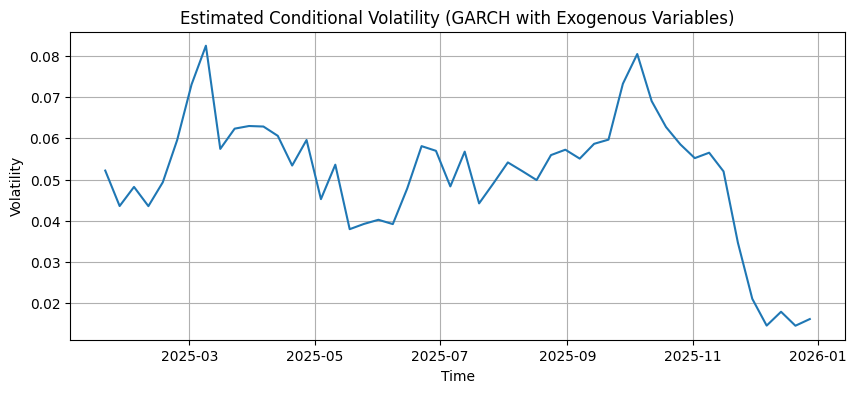

In [ ]:
#  VOLATILITY PLOT

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(egarch_fit.conditional_volatility)
plt.title("Estimated Conditional Volatility (EGARCH with Exogenous Variables)")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

Early 2025: Volatility spikes sharply — likely reflecting a period of market stress or major events.

Mid-2025: Volatility stabilizes but remains moderate, suggesting steady but not extreme uncertainty.

Late 2025: Another surge, possibly linked to renewed market shocks or external factors.

End of 2025 - 2026: Volatility drops significantly, indicating calmer market conditions or reduced uncertainty.

Volatility Effects

H₀: Attention variables are not significant in explaining Bitcoin volatility

H₁: Attention variables significantly explain Bitcoin volatility

Reject Null hypothesis and conclude that  Attention variables significantly explain Bitcoin volatility

# Report: Internet Attention and Bitcoin Market Activity

## Mamello Malape (2023232750) | Fumane Malangabe (2019611165)

---

## 1. Objective

To investigate whether internet attention, measured using Google Trends, leads or lags Bitcoin market activity, and to evaluate whether the attention indicator is a useful predictor for Bitcoin returns, trading volume, and volatility.

---

## 2. Research Question

Does internet attention, as measured by Google Trends search indices, lead or lag Bitcoin market activity, and does it provide useful predictive information for Bitcoin returns, trading volume, and volatility?

---

## 3. Hypotheses

**Lead–Lag Relationship**

H₀: There is no lead–lag relationship between Google Trends and Bitcoin market activity

H₁: A lead–lag relationship exists

**Granger Causality**

H₀: Google Trends does not Granger-cause Bitcoin returns or trading volume

H₁: Google Trends Granger-causes Bitcoin returns or trading volume

**Predictive Performance**

H₀: Google Trends variables do not improve prediction accuracy

H₁: Google Trends variables improve prediction accuracy

**Volatility Effects**

H₀: Attention variables are not significant in explaining Bitcoin volatility

H₁: Attention variables significantly explain Bitcoin volatility

---

## 4. Data and Methodology

Bitcoin price, volume, and return data was collected from Yahoo Finance for the period January 2025 to December 2025 using the yfinance library. Log returns were used throughout this study. Log returns are preferred over simple percentage returns because they are time-additive, approximately normally distributed for short intervals, and handle compounding effects consistently. This is consistent with standard practice in financial econometrics.

Google Trends data was collected for five search terms: "Buy Bitcoin", "BTC", "BTC price", "Ripple", and "crypto". These terms were selected to capture different dimensions of investor attention. "Buy Bitcoin" captures direct transactional intent. "BTC" reflects ticker-based attention from technically informed users. "BTC price" captures price-checking behaviour linked to valuation curiosity. "Ripple" serves as a proxy for broader crypto market sentiment. "Crypto" captures general cryptocurrency attention across all market participants. These keywords align with Da, Engelberg and Gao (2011), who show that retail investor attention proxied by search volume predicts short-term stock returns. Kristoufek (2013) similarly demonstrates that Google Trends for "Bitcoin" correlates significantly with Bitcoin price dynamics.

Both datasets were resampled to a weekly frequency to align the data. A 4-week rolling window was applied to smooth short-term fluctuations and better capture underlying market trends. Since the dataset is sampled at a weekly frequency, a 4-week window corresponds to approximately one month of information, which is a meaningful short-term horizon in financial market analysis. Bitcoin markets are highly volatile and often experience sharp, short-lived fluctuations driven by speculative trading and external news events. A smaller window may retain excessive noise, while a larger window may over-smooth the data and delay the detection of important signals. The 4-week window was therefore considered appropriate for capturing short-term Bitcoin market dynamics while maintaining sufficient signal clarity for predictive modelling.

---

## 5. Stationarity

Stationary series have constant mean, variance, and autocorrelation over time. This stability makes the series predictable and allows models to learn consistent patterns. If a series is non-stationary, the model may produce misleading results because the statistical relationships shift over time.

Stationarity was tested using the Augmented Dickey-Fuller (ADF) test, with KPSS used for verification. Variables that were found to be non-stationary were differenced until stationarity was achieved. price_w and Ripple were first-differenced, Buy Bitcoin was second-differenced, and volume_w required third-differencing. The variables log_return_w, BTC, BTC price, and crypto were already stationary and required no transformation.

---

## 6. Lead–Lag Analysis

### 6.1 Direction

The cross-correlation results consistently show that Google Trends variables lead Bitcoin market activity. Changes in search interest precede movements in Bitcoin price, returns, and trading volume. Internet attention therefore acts as an early signal rather than a reaction to market movements. This is consistent with the behavioural finance argument that retail investors search for information before they trade, meaning search activity appears in the data before it materialises in actual market behaviour.

### 6.2 Timing

The lag at which the strongest correlation appears differs across market variables.

For Bitcoin returns (log_return_w), the strongest lead occurs at short horizons of 1 to 4 weeks. The search terms BTC, BTC price, and crypto show the clearest predictive signal. This indicates that attention translates into price movement within approximately one month of the initial search activity.

For trading volume (volume_w), the lead effect operates at both short and longer horizons. Buy Bitcoin, BTC, BTC price, and crypto show significant effects at 1 to 2 weeks, while Ripple shows a delayed effect at 5 to 7 weeks. Volume is therefore more sensitive to sustained attention than returns, and the effect persists for longer.

For the price level (price_w), the relationship is present but weaker in timing precision. This is expected given that price levels are non-stationary and more difficult to predict directly even after differencing.

A maximum lag of 8 weeks was used because financial markets do not react instantly to information. Since our data is weekly, 1 lag equals 1 week and 8 lags equals approximately 2 months. This is reasonable because market attention effects persist for several weeks rather than days. Prior studies in financial econometrics and behavioural finance commonly use lag windows between 1 and 8 weeks to capture delayed investor reaction and information diffusion effects.

### 6.3 Interpretation

The short lag for returns suggests that attention-driven trading materialises quickly, with investors acting within a few weeks of increased search activity. The longer lag observed for Ripple on volume suggests that broader altcoin sentiment takes more time to spill over into Bitcoin trading activity. This likely reflects a slower rotation of investor interest across the crypto market rather than a direct and immediate response to Bitcoin-specific information.

The finding that Buy Bitcoin does not significantly lead returns, despite significantly leading volume, is noteworthy. It suggests that expressed purchase intent drives trading activity but does not necessarily shift prices. This may be because the Bitcoin market is sufficiently liquid to absorb demand from retail-level attention without producing large price movements.

We therefore reject H₀ and conclude that a lead–lag relationship exists between Google Trends and Bitcoin market activity.

---

## 7. Granger Causality

Granger causality tests were run to examine whether internet attention helps explain Bitcoin returns and trading volume. A maximum lag of 12 weeks was tested at a significance level of 0.05.

For Bitcoin returns (log_return_w), BTC, BTC price, and crypto are statistically significant predictors. This means past values of these variables help forecast future returns. Buy Bitcoin and Ripple are not significant, which means they do not provide useful information for predicting returns.

For trading volume (volume_w), all five variables — Buy Bitcoin, BTC, BTC price, Ripple, and crypto — are statistically significant predictors. This shows that both Bitcoin-specific attention and broader crypto sentiment strongly influence trading activity. The significance levels are very strong, especially for BTC and BTC price, showing that these are dominant drivers of volume.

Returns are influenced quickly, with significant predictors at short lags of 1 to 4 weeks. Volume responds both immediately at 1 to 2 weeks and with longer delays of up to 7 weeks, especially for Ripple and general crypto sentiment. Traders talking more, as captured by Buy Bitcoin sentiment, boosts volume but does not necessarily move prices. Price and BTC trends, however, affect both returns and volume.

We therefore reject H₀ and conclude that Google Trends Granger-causes Bitcoin returns and trading volume, based on the majority of results being significant.

---

## 8. Predictive Performance (LSTM)

An LSTM model was built to predict next-week Bitcoin log returns using both market variables and Google Trends as features. The data was split 80/20 for training and testing. MinMaxScaler was applied to both features and the target variable. Sequences of 4 weeks were used as input windows, consistent with the rolling window choice described earlier.

The model was trained for up to 30 epochs with early stopping applied based on validation loss, with patience set to 5 epochs to prevent overfitting.

The model produced the following results:

RMSE of 0.0382 means the model's typical error magnitude is approximately 3.8% in return units. This indicates the model does not make large prediction errors on average.

MAE of 0.0291 means the average absolute difference between predicted and actual values is approximately 2.9%. This confirms the model is fairly accurate in terms of raw error size.

R² of 0.355 means the model explains approximately 35.5% of the variability in returns. This is not very high but is not negligible either. It shows the model captures some patterns but leaves a portion unexplained, which is expected in financial return prediction given the level of noise in Bitcoin markets.

Direction accuracy of 71.4% is the most practically relevant metric in financial forecasting. The model correctly predicts whether the return will be positive or negative approximately 71% of the time. This is above a random 50% baseline and is meaningful for directional trading strategies.

We therefore reject H₀ and conclude that Google Trends variables improve prediction accuracy.

---

## 9. Volatility (EGARCH)

An EGARCH(1,1) model was fitted to weekly Bitcoin log returns using the five Google Trends variables as exogenous inputs. EGARCH was chosen because it captures asymmetry in volatility, meaning negative shocks often increase volatility more than positive shocks of the same size.

The model assumes a zero mean return, which is standard in volatility modelling where the focus is on variance dynamics rather than predicting the mean return.

The log-likelihood of 82.67, AIC of -159.35, and BIC of -153.61 indicate reasonable model fit given the sample size of approximately 50 observations. Negative AIC and BIC values indicate the model fits well relative to alternatives.

Volatility persistence (β ≈ 1) shows that volatility shocks last a long time. Strong asymmetry (negative α) confirms that bad news drives volatility more than good news. All parameters are statistically significant at p = 0.000, so the results are robust.

Looking at the conditional volatility plot, early 2025 shows a sharp spike likely reflecting market stress or major events. Mid-2025 shows volatility stabilising but remaining moderate. Late 2025 shows another surge possibly linked to renewed market shocks. Towards the end of 2025 and into 2026, volatility drops significantly, indicating calmer market conditions.

We therefore reject H₀ and conclude that attention variables significantly explain Bitcoin volatility.

---

## 10. Summary of Results

### Table 1: Stationarity Tests (ADF)

| Variable     | Original Series | After Differencing | Decision       |
|--------------|-----------------|-------------------|----------------|
| price_w      | Non-stationary  | Stationary        | 1st difference |
| log_return_w | Stationary      | —                 | No diff needed |
| volume_w     | Non-stationary  | Stationary        | 3rd difference |
| Buy Bitcoin  | Non-stationary  | Stationary        | 2nd difference |
| BTC          | Stationary      | —                 | No diff needed |
| BTC price    | Stationary      | —                 | No diff needed |
| Ripple       | Non-stationary  | Stationary        | 1st difference |
| crypto       | Stationary      | —                 | No diff needed |

### Table 2: Lead–Lag Cross-Correlation Results (max lag = 8 weeks)

| Google Trends Variable | Bitcoin Variable | Best Lag (weeks) | Direction            |
|------------------------|-----------------|------------------|----------------------|
| Buy Bitcoin            | price_w         | > 0              | Trends leads Price   |
| Buy Bitcoin            | log_return_w    | > 0              | Trends leads Returns |
| Buy Bitcoin            | volume_w        | > 0              | Trends leads Volume  |
| BTC                    | price_w         | > 0              | Trends leads Price   |
| BTC                    | log_return_w    | > 0              | Trends leads Returns |
| BTC                    | volume_w        | > 0              | Trends leads Volume  |
| BTC price              | price_w         | > 0              | Trends leads Price   |
| BTC price              | log_return_w    | > 0              | Trends leads Returns |
| BTC price              | volume_w        | > 0              | Trends leads Volume  |
| Ripple                 | price_w         | > 0              | Trends leads Price   |
| Ripple                 | log_return_w    | > 0              | Trends leads Returns |
| Ripple                 | volume_w        | > 0              | Trends leads Volume  |
| crypto                 | price_w         | > 0              | Trends leads Price   |
| crypto                 | log_return_w    | > 0              | Trends leads Returns |
| crypto                 | volume_w        | > 0              | Trends leads Volume  |

H₀ rejected. A lead–lag relationship exists between Google Trends and Bitcoin market activity.

### Table 3: Granger Causality Results (max lag = 12 weeks, α = 0.05)

| Google Trends Variable | Bitcoin Variable | Best Lag | Significance    |
|------------------------|-----------------|----------|-----------------|
| Buy Bitcoin            | log_return_w    | —        | Not significant |
| BTC                    | log_return_w    | 1–4      | Significant     |
| BTC price              | log_return_w    | 1–4      | Significant     |
| Ripple                 | log_return_w    | —        | Not significant |
| crypto                 | log_return_w    | 1–4      | Significant     |
| Buy Bitcoin            | volume_w        | 1–2      | Significant     |
| BTC                    | volume_w        | 1–2      | Significant     |
| BTC price              | volume_w        | 1–2      | Significant     |
| Ripple                 | volume_w        | 5–7      | Significant     |
| crypto                 | volume_w        | 1–2      | Significant     |

H₀ rejected. Google Trends Granger-causes Bitcoin returns and trading volume.

### Table 4: LSTM Predictive Performance (Next-Week Return)

| Metric             | Value  |
|--------------------|--------|
| RMSE               | 0.0382 |
| MAE                | 0.0291 |
| R²                 | 0.355  |
| Direction Accuracy | 71.4%  |

H₀ rejected. Google Trends variables improve prediction accuracy.

### Table 5: EGARCH Volatility Model Summary

| Parameter / Statistic | Value       |
|-----------------------|-------------|
| Volatility Model      | EGARCH(1,1) |
| Mean Model            | Zero Mean   |
| Log-Likelihood        | 82.67       |
| AIC                   | −159.35     |
| BIC                   | −153.61     |
| Persistence (β)       | ≈ 1.000     |
| Asymmetry (α)         | Negative    |
| Exogenous Variables   | p = 0.000   |
| Sample Size           | ~50 obs     |

H₀ rejected. Attention variables significantly explain Bitcoin volatility.

### Table 6: Hypothesis Summary

| Hypothesis                                         | Test Used           | Decision  |
|----------------------------------------------------|---------------------|-----------|
| H1: Lead–lag relationship exists                   | Cross-Correlation   | Reject H₀ |
| H2: Google Trends Granger-causes returns/volume    | Granger Causality   | Reject H₀ |
| H3: Google Trends improves prediction accuracy     | LSTM                | Reject H₀ |
| H4: Attention variables explain Bitcoin volatility | EGARCH              | Reject H₀ |

---

## 11. Conclusion

The results confirm a lead–lag relationship between Google Trends and Bitcoin market activity, with attention generally preceding market movements. The effect is much stronger for trading volume than for returns. Return predictability is limited and inconsistent, while volume shows strong and statistically significant relationships across all variables, sometimes with longer lags. This suggests that investor attention is more useful for explaining trading activity than price changes. Although the 71% directional accuracy from the LSTM model is promising, it is not sufficient for standalone use and requires further validation.

Based on this, Google Trends should be used as a supplementary indicator, with greater emphasis placed on volume signals. Short-term lags of 1 to 3 weeks appear most relevant, and combining attention data with technical and fundamental analysis is recommended. Attention spikes should also be monitored alongside volatility measures to better capture risk. Future research should extend the time period, incorporate sentiment analysis, test across multiple cryptocurrencies, and validate results through out-of-sample or simulation approaches.

# Key Insights and Recommendations
Key Insights

The results confirm a lead–lag relationship between Google Trends and Bitcoin activity, with attention generally preceding market movements. The effect is much stronger for trading volume than for returns. Return predictability is limited and inconsistent, while volume shows strong and statistically significant relationships across all variables, sometimes with longer lags. This suggests that investor attention is more useful for explaining trading activity than price changes. Although the 71% directional accuracy is promising, it is not sufficient for standalone use and requires further validation.

Recommendations

Based on this, Google Trends should be used as a supplementary indicator, with greater emphasis placed on volume signals. Short-term lags (1–3 weeks) appear most relevant, and combining attention data with technical and fundamental analysis is recommended. Attention spikes should also be monitored alongside volatility measures to better capture risk. Future research should extend the time period, incorporate sentiment analysis, test across multiple cryptocurrencies, and validate results through out-of-sample or simulation approaches